# 数据收集与项目结构思考
我们现在开始做这个data visualization的项目。在正式开始之前，我想先仔细考虑一下我要研究的问题，以及处理策略。

首先是，我想研究的问题是，关于**平价购买力**，**工资**，**工作领域**，**学历**等概念的。我目前只是对这些概念比较感兴趣，还没有明确的研究问题。也许我可以先从数据搜索开始。

关于评价购买力，我在世界银行找到了各个国家和地区的历年人均和总量的PPP数据。

总量：https://data.worldbank.org/indicator/NY.GDP.MKTP.PP.CD

GDP, PPP (current international $)

放在了*API_NY.GDP.MKTP.PP.CD_DS2_en_csv_v2_304*这个文件夹里面

人均：https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.CD

GDP per capita, PPP (current international $)

放在了*API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_35*这个文件夹里面

不过，世界银行WorldBank的数据只有24年的，我发现IMF有2025年的数据，甚至他们还按照惯例进行了预测。

人均PPP：https://www.imf.org/external/datamapper/PPPPC@WEO/OEMDC/ADVEC/WEOWORLD

这个链接里下载来的是*imf-dm-export-20260225.xls*，经过确认是人均PPP，而非人均名义GDP

不过，GPT说，世界银行最权威、细致，更加侧重国家之间真是生活成本比较，这些底层数据也都来自一个叫ICP的项目，这是一个物价调查项目，而这个项目是由世界银行牵头的。IMF则更加侧重宏观经济，联合国的数据则侧重人类发展。由此，我觉着还是世界银行的数据比较好，尽管可能慢一点。

我还下载了PPP转换因子的数据。地址是：

https://data.worldbank.org/indicator/PA.NUS.PPP

放在*API_PA.NUS.PPP_DS2_en_csv_v2_94*这个文件夹里。

我在联合国那里下载了详细的世界人口数据，当然最主要的就是各国各地区的人口，可惜只到2023年

https://population.un.org/wpp/downloads?folder=Standard%20Projections&group=Most%20used

放在*WPP2024_GEN_F01_DEMOGRAPHIC_INDICATORS_COMPACT.xlsx*

不过我随后发现，世界银行也有人口数据，而且似乎比联合国的更加详细。不过实际上人口数据一般都是推算的，正常国家都是好几年才普查一次。所以也许我可以使用这种同样权威的人口数据。

https://databank.worldbank.org/source/population-estimates-and-projections#

*P_Data_Extract_From_Population_estimates_and_projections*

我发现有很多数据都是分开不同性别的，但是性别平等问题是非常复杂的，并且有非常多独立的衡量指数，我们此处只关注宏观整体数据。

我又考虑了一下，我认为我们需要涉及的维度有很多，至少要有税收，还有就是社会结构本身。我们可能需要平均数据，但是也必须要搞清楚整个社会的贫富差距，或者至少是学历差距。至于就业率，我认为这也许很重要，但就业率对一个国家而言不一定是长期问题（这句话也许需要验证），但总之我们也许不需要就业率的修正。还有Gemini告诉我了一个非常重要的维度，就是就业市场的供求关系，该领域的毕业生有多少

所以我们需要涉及的维度应该有：

1. 年份
2. 工资
3. 税收（可用可支配收入取代）
4. 平均工资
5. 平价购买力√
6. 不同领域的收入
7. 不同学历的收入
8. 人口√
9. 不同领域的毕业生数量



我在OECD网站上面下载到了一些国家的平均年工资数据，但是问题是，非常不全，只有40多个国家，好像是OECD组织成员国的数据，但最离谱的是竟然没有中国，所以直接使用这里面的国家，其他的弃用的这种想法，不太可行。

https://data-explorer.oecd.org/vis?fs[0]=Topic%2C0%7CEmployment%23JOB%23&fs[1]=Topic%2C1%7CEmployment%23JOB%23%7CBenefits%252C%20earnings%20and%20wages%23JOB_BW%23&pg=0&fc=Topic&snb=21&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_EARNINGS%40AV_AN_WAGE&df[ag]=OECD.ELS.SAE&df[vs]=1.0&dq=AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BOECD%2BBGR%2BHRV%2BROU..AUD%2BBGN%2BCAD%2BCHF%2BCLP%2BCOP%2BCRC%2BCZK%2BDKK%2BEUR%2BGBP%2BHUF%2BILS%2BISK%2BJPY%2BKRW%2BMXN%2BNOK%2BNZD%2BPLN%2BRON%2BSEK%2BTRY%2BUSD%2BUSD_PPP..Q%2BV..&pd=2000%2C&to[TIME_PERIOD]=false

*OECD.ELS.SAE,DSD_EARNINGS@AV_AN_WAGE,1.0+all.csv*

worldbank倒是有关于jobs的数据，好像是分领域的，可惜最新就截止到2016年，实在是没法用，十年前十年后天差地别。


我在IMF看到了一个包含时间各国CPI和就业率、失业率的数据。好像还有什么revenue之类的

https://data.imf.org/en/Data-Explorer?datasetUrn=IMF.RES:WEO(9.0.0)&INDICATOR=GGR

*dataset_2026-02-26T00_46_37.456194563Z_DEFAULT_INTEGRATION_IMF.RES_WEO_9.0.0.csv*

在时间银行找到了净收入的数据，可惜只到2021年

https://databank.worldbank.org/source/adjusted-net-savings#

*API_NY.GDP.MKTP.KD.ZG_DS2_zh_csv_v2_6130*

关于税收之类的，我想了一下，因为我可以直接用净收入，税收本来就非常难计算，对于个人来讲，可能各个地区的还不一样，然后还可能面临累进税率，还有消费税等等问题。我们干脆简单粗暴使用可支配收入来代替就好了。也许，我们可以查一下可支配收入的中位数之类的。

那么，目前我们应该考虑的维度就应该是这样的：

1. 年份√
2. 平均可支配收入√（只到21年）
3. 平价购买力√(source: worldbank)
4. 不同学历的收入
5. 人口√(source: worldbank)
6. 不同领域的收入
7. 不同领域的毕业生数量

这个时候，我们就发现了，平均可支配收入、平价购买力、人口等等都是**背景信息**，而真正要做的就是分组研究，我们正好可以分成两个子问题，一个是**不同学历**的收入的研究，一个是**不同领域**的分组研究。并且我们现在也可以差不多准备定义我们的问题了：

大问题：平价购买力与STEM，学生的就业问题
1. 作为某个STEM专业的学生，哪些国家更适合自己的发展呢，或者至少哪些国家更愿意为STEM专业学生支付溢价？
2. 作为某个学历的学生，哪些国家更加适合自己发展呢？或者不同国家的社会环境是如何的？（公平性与效率性的双重考量）
3. 某个国家对STEM和高学历的溢价，是否与国家工业发展有关？

那么现在在想来，其实我好多数据都可以删掉。我真正需要的只有4种，如果可以直接找到的话。

1 各国人均平价购买力（已经找到）

2 各国STEM从业人员平价购买力

3 各国不同学历平价购买力

4 各国某个工业或经济发展的指标

这里面还有些坑，导致实际上本来就不好找的数据集更不好找了。

第一个是，人均平价购买力也不等于可支配收入，所以可能会有平价购买力超高，但是实际上买不了多少东西的情况。这个最麻烦的在于，我们不仅需要人均可支配平价购买力，我们还需要STEM里的，还有不同学历里的人均可支配平价购买力。

第二个是，STEM的定义，以及专门的数据集是一个大问题

按照gemini的说法，关于第一点，我们可以下载各国的“平均个人所得税率”或“税收楔子 (Tax Wedge)”，然后进行估算。还有个办法就是直接大大方方承认数据的局限性，如此做法一定大幅低估了高税收国家的生存压力。

关于第二点，就是要查阅一些元数据，如去看国际教育标准分类（ISCED）里面的STEM是怎么定义的，然后去找对应的专业人员，最后加起来之类的


我找到了OECD的Taxing wages数据，不错，这样至少OECD的人均真正可支配收入就可以计算了

https://www.oecd.org/en/publications/taxing-wages_20725124.html

更简单的数据可以在这个pdf里看到：

https://www.oecd.org/content/dam/oecd/en/topics/policy-issues/tax-policy/taxing-wages-brochure.pdf

同时，我还找到了所有国家的tax rate，是wiki页面，只不过我有点怀疑这个数据的可靠性。

https://en.wikipedia.org/wiki/List_of_countries_by_tax_rates

不过我们姑且这方面的数据是有了，至少现在我们可以计算任何一个国家的实际人均平价购买力了。并且由于有税率的存在，我们找其他的数据的时候，也可以更加灵活一些，比如可以先找到本国货币的收入，再扣去税率，再统一使用购买力转换因子转化之类的。

那么接下来，我们就需要找各国STEM人员的收入，和各国不同学历水平的收入。

首先，我倒是在世界银行看到了各国的STEM毕业生的比例，但是这个和我们的需求没有直接关系，不过数据在这里：

https://databank.worldbank.org/id/cd77ac48

然后这里也有一篇，提到了各国的占比，他们提到他们用的是UNESCO和OECD的数据库。

https://cset.georgetown.edu/article/the-global-distribution-of-stem-graduates-which-countries-lead-the-way/

然后，我找到了OECD的不同学历收入对比，数据在这两页：

https://www.oecd.org/en/topics/earnings-by-educational-attainment.html

https://www.oecd.org/en/publications/education-at-a-glance-2024_c00cad36-en.html

经过一番寻找，我们目前的数据有：
* 各国的人均平价购买力
* 各国的国家人均tax wedge
* 各国的STEM毕业生比例
* OECD的不同学历收入比例

那么，我们只需要找到世界各国的不同学历收入比例，就可以处理全球的数据了

不过，我又想了一下，还是尽快完成这个任务吧，时间有限，加上老师既然有推荐数据库，那么就正好用这些数据吧。

好，我们终于开始正式的数据处理。首先，我们有个基本原则，由于涉及的内容不多，我们可以把所有数据放到一个表格中。大概目标是下面的形式：


| 国家代号 | 年份   | 人均平价购买力 |人均tax wedge|人均税后平价购买力|STEM毕业生比例|基础教育收入|大学教育收入|更高等教育收入| 工业指标 |
|:-----|:-----|:--------|:---|:---|:---|:---|:---|:---|:-----|
| USA  | 2015 | 123153  | 35% | 156154| 35% | 156165| 156165| 156516 | 5644 |
| USA  | 2016 | 123153  | 35% | 156154| 35% | 156165| 156165| 156516 | 5644 |
| ...  | ...  | ...     | ... | ...| ... | ...| ...| ... | ...  |
| CHN  | 2015 | 123153  | 35% | 156154| 35% | 156165| 156165| 156516 | 5644 |


# 数据处理


## PPP数据
那么首先，我们需要拿来国家与平价购买力的表格。由于前面有几行非结构化数据，我们直接跳过

In [75]:
import pandas as pd
from pandas import read_csv

df_PPP = pd.read_csv("PPP.csv", skiprows=4)
df_PPP.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,37524.914920,39287.059713,38543.907294,28854.597300,35104.786804,41758.895757,46574.357420,50649.301523,NaN,NaN
1,Africa Eastern and Southern,AFE,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3837.726375,3723.216423,3801.413183,3708.094649,4028.376504,4369.191056,4501.601101,4635.788224,NaN,NaN
2,Afghanistan,AFG,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2335.795862,2432.276701,2583.485332,2561.981761,2144.166570,2122.995815,2201.722907,NaN,NaN,NaN
3,Africa Western and Central,AFW,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,5026.648499,5179.359990,5484.249418,5414.042540,5690.967743,6220.122875,6520.280313,6815.990961,NaN,NaN
4,Angola,AGO,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,8006.836615,8278.368862,8572.878956,7827.428043,8862.281333,9588.241295,9753.600468,10118.608995,NaN,NaN


很好，这样表格就是结构化的了。接下来我们看一下表格基本信息。

In [76]:
df_PPP.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      float64
 18  1

我们发现，首先是前面几年都是全空的，我们肯定要直接删掉。有些国家后面也有几年是空的，我们一会儿再处理。接下来我们先删去那个`Indicator Name`和`Indicator Code`，以及`1960`-`1989`列。

In [77]:
print(df_PPP.columns.tolist())

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [78]:
df_PPP.drop(columns=["Indicator Name", "Indicator Code"], inplace=True)
print(df_PPP.columns.tolist())

['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [79]:
years_to_drop = [str(x) for x in range(1960, 1990)]
df_PPP.drop(columns=years_to_drop, inplace=True)
print(df_PPP.columns.tolist())

['Country Name', 'Country Code', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'Unnamed: 70']


In [80]:
df_PPP.drop(columns=["Unnamed: 70","2025"], inplace=True)

In [81]:
df_PPP.head()

,Country Name,Country Code,1990,1991,1992,1993,1994,1995,1996,1997,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,21732.858315,23099.940085,23889.045018,24575.660660,25791.043179,26254.742804,26004.495628,27240.802789,...,35972.859662,36117.535262,37524.914920,39287.059713,38543.907294,28854.597300,35104.786804,41758.895757,46574.357420,50649.301523
1,Africa Eastern and Southern,AFE,1851.172551,1866.163505,1820.062818,1807.249785,1832.163205,1903.826539,1994.831064,2063.257707,...,3539.815506,3634.441673,3837.726375,3723.216423,3801.413183,3708.094649,4028.376504,4369.191056,4501.601101,4635.788224
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2284.075848,2213.181441,2335.795862,2432.276701,2583.485332,2561.981761,2144.166570,2122.995815,2201.722907,NaN
3,Africa Western and Central,AFW,2128.812260,2167.919776,2213.876162,2177.109793,2158.470111,2180.440934,2259.840956,2331.208775,...,5056.739439,4965.330229,5026.648499,5179.359990,5484.249418,5414.042540,5690.967743,6220.122875,6520.280313,6815.990961
4,Angola,AGO,3704.863177,3740.350835,3486.206867,2627.588101,2632.888199,2989.761380,3341.911888,3525.083430,...,8067.485847,7766.837875,8006.836615,8278.368862,8572.878956,7827.428043,8862.281333,9588.241295,9753.600468,10118.608995


还有一步差点忘记了，就是我们现在已经决定只处理OECD国家了，那么我们接下来应该删掉非OECD国家。不过我们稍后使用现成的OECD国家列表来处理。

## Taxing Wedges
好，现在我们删干净了这个PPP的表格，我们接下来要把其他数据整合到这个里面去。下一步，Taxing Wedges。本来，我们的数据是在pdf上下载的，不过现在，我们找到了原始的数据集，这样的正规许多：

https://data-explorer.oecd.org/vis?df[ds]=DisseminateFinalDMZ&df[id]=DSD_TAX_WAGES_COMP%40DF_TW_COMP&df[ag]=OECD.CTP.TPS&dq=.AV_TW..S_C0.AW100._Z.A&lom=LASTNPERIODS&lo=10&to[TIME_PERIOD]=false&vw=tb

In [82]:
df_taxing_wedge = pd.read_csv("OECD_Taxing_Wedges.csv")
df_taxing_wedge.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,...,OBS_VALUE,Observation value,DECIMALS,Decimals,UNIT_MULT,Unit multiplier,OBS_STATUS,Observation status,CIVIL_STATUS,Civil status
0,DATAFLOW,OECD.CTP.TPS:DSD_TAX_WAGES_COMP@DF_TW_COMP(2.1),Labour taxation – OECD comparative country ind...,I,AUS,Australia,AV_TW,Average tax wedge,PT_COS_LB,Percentage of labour costs,...,27.904344,NaN,2,Two,0,Units,A,Normal value,_Z,Not applicable
1,DATAFLOW,OECD.CTP.TPS:DSD_TAX_WAGES_COMP@DF_TW_COMP(2.1),Labour taxation – OECD comparative country ind...,I,AUS,Australia,AV_TW,Average tax wedge,PT_COS_LB,Percentage of labour costs,...,29.575775,NaN,2,Two,0,Units,A,Normal value,_Z,Not applicable
2,DATAFLOW,OECD.CTP.TPS:DSD_TAX_WAGES_COMP@DF_TW_COMP(2.1),Labour taxation – OECD comparative country ind...,I,AUS,Australia,AV_TW,Average tax wedge,PT_COS_LB,Percentage of labour costs,...,29.189745,NaN,2,Two,0,Units,A,Normal value,_Z,Not applicable
3,DATAFLOW,OECD.CTP.TPS:DSD_TAX_WAGES_COMP@DF_TW_COMP(2.1),Labour taxation – OECD comparative country ind...,I,AUS,Australia,AV_TW,Average tax wedge,PT_COS_LB,Percentage of labour costs,...,27.047225,NaN,2,Two,0,Units,A,Normal value,_Z,Not applicable
4,DATAFLOW,OECD.CTP.TPS:DSD_TAX_WAGES_COMP@DF_TW_COMP(2.1),Labour taxation – OECD comparative country ind...,I,AUS,Australia,AV_TW,Average tax wedge,PT_COS_LB,Percentage of labour costs,...,27.044338,NaN,2,Two,0,Units,A,Normal value,_Z,Not applicable


我们发现大部分的数据是没用的，我们直接删掉其他的部分，留下我们所需要的。还需注意的是，这个表格里的年份居然是竖着的，是分在不同列的。不过首先还是先删掉其他没用的列。

In [83]:
columns_to_keep = ["REF_AREA", "OBS_VALUE", "TIME_PERIOD"]
df_taxing_wedge = df_taxing_wedge[columns_to_keep]

In [84]:
df_taxing_wedge.head()

,REF_AREA,OBS_VALUE,TIME_PERIOD
0,AUS,27.904344,2025
1,AUS,29.575775,2024
2,AUS,29.189745,2023
3,AUS,27.047225,2022
4,AUS,27.044338,2021


这下干净多了，我们接下来把数据放进原来的总表里面。不过在合并之前，我们先提取出来国家列表，用作清理原来的PPP表格。

In [85]:
OECD_country_list = df_taxing_wedge['REF_AREA'].unique().tolist()
print("应有国家数量38，实际上提取国家数量：",len(OECD_country_list))

应有国家数量38，实际上提取国家数量： 40


这就有意思了，多了2个，我看了一下，一个是OECD_REP，表示OECD平均值，一个是EU22OECD，表示欧盟的值。我们把这两个也删掉。

In [86]:
OECD_country_list.remove("OECD_REP")
OECD_country_list.remove("EU22OECD")
print("应有国家数量38，实际上提取国家数量：",len(OECD_country_list))

应有国家数量38，实际上提取国家数量： 38


这样，我们就可以用这个list筛一遍原来的PPP表格。

In [87]:
compare_bool_list = df_PPP["Country Code"].isin(OECD_country_list)
df_PPP = df_PPP[compare_bool_list]

In [88]:
df_PPP.info()

<class 'pandas.DataFrame'>
Index: 38 entries, 13 to 251
Data columns (total 37 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  38 non-null     str    
 1   Country Code  38 non-null     str    
 2   1990          38 non-null     float64
 3   1991          38 non-null     float64
 4   1992          38 non-null     float64
 5   1993          38 non-null     float64
 6   1994          38 non-null     float64
 7   1995          38 non-null     float64
 8   1996          38 non-null     float64
 9   1997          38 non-null     float64
 10  1998          38 non-null     float64
 11  1999          38 non-null     float64
 12  2000          38 non-null     float64
 13  2001          38 non-null     float64
 14  2002          38 non-null     float64
 15  2003          38 non-null     float64
 16  2004          38 non-null     float64
 17  2005          38 non-null     float64
 18  2006          38 non-null     float64
 19  200

这下PPP list就已经只有38个OECD国家了，而且我们惊喜的发现，这些国家是没有空数值的，非常好。接下来，我们要想办法把这些年份的列都合并成一个长表格，改成这样的格式：
|Country Code| Year | Value|
|:----------|:-----|:-----|
|USA         |1990  | 123|
|USA         |1991  | 123|
|...         |...  | ...|
|CHN         |1990  | 123|
|CHN         |1991  | 123|



In [89]:
df_PPP_block = pd.melt(
    df_PPP,
    id_vars=["Country Code","Country Name"],
    var_name="Year",
    value_name="PPP",
)

In [90]:
df_PPP_block.head(10)

,Country Code,Country Name,Year,PPP
0,AUS,Australia,1990,17385.498542
1,AUT,Austria,1990,19395.859899
2,BEL,Belgium,1990,18687.725796
3,CAN,Canada,1990,20225.960108
4,CHE,Switzerland,1990,28461.237766
5,CHL,Chile,1990,4444.466727
6,COL,Colombia,1990,5109.420001
7,CRI,Costa Rica,1990,5020.635941
8,CZE,Czechia,1990,12848.248412
9,DEU,Germany,1990,19467.815031


这样，表格已经非常漂亮了，不过我们还需要排序一下。我们按照国家代码升序，在国家代码相同的时候，按照year升序

In [91]:
df_PPP_block.sort_values(by=["Country Code", "Year"], inplace=True, ignore_index=True)

In [94]:
df_PPP_block.head(120)

,Country Code,Country Name,Year,PPP
0,AUS,Australia,1990,17385.498542
1,AUS,Australia,1991,17839.057471
2,AUS,Australia,1992,18258.723436
3,AUS,Australia,1993,19220.342291
4,AUS,Australia,1994,20173.633537
...,...,...,...,...
115,CAN,Canada,2000,29347.787980
116,CAN,Canada,2001,30241.032653
117,CAN,Canada,2002,30963.921886
118,CAN,Canada,2003,32349.882958


In [95]:
df_PPP_block.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  1330 non-null   str    
 1   Country Name  1330 non-null   str    
 2   Year          1330 non-null   str    
 3   PPP           1330 non-null   float64
dtypes: float64(1), str(3)
memory usage: 41.7 KB


非常好，这样，这里第一个模块PPP就准备好了，接下来我们来把刚刚的taxing wedge的也合并进去。

In [96]:
df_taxing_wedge.head(120)

,REF_AREA,OBS_VALUE,TIME_PERIOD
0,AUS,27.904344,2025
1,AUS,29.575775,2024
2,AUS,29.189745,2023
3,AUS,27.047225,2022
4,AUS,27.044338,2021
...,...,...,...
115,DEU,49.469332,2018
116,DEU,49.539002,2017
117,GRC,39.337030,2025
118,GRC,39.499068,2024


我们发现，这个taxing wedge的表格是倒序的，首先需要排序。而且还有个问题，似乎数据没有那么多年的，只有从2017年开始的。

In [97]:
df_taxing_wedge.sort_values(by=["REF_AREA","TIME_PERIOD"], inplace=True, ignore_index=True)
df_taxing_wedge.head(120)

,REF_AREA,OBS_VALUE,TIME_PERIOD
0,AUS,28.570916,2016
1,AUS,28.616701,2017
2,AUS,28.889201,2018
3,AUS,27.940358,2019
4,AUS,28.358919,2020
...,...,...,...
115,ESP,39.867712,2021
116,ESP,40.046618,2022
117,ESP,40.754816,2023
118,ESP,41.136398,2024


接下来就比较麻烦了，我们需要把含有国家和年份的数据统一扔进去，但是他们的年份又不一样，我们需要首先按照国家代码对齐，在国家代码对齐的同时，再按照年份排序。也就是说，这是一个双主键配对。不过再开始之前，我们得保证键名是一致的。我们改一下

In [98]:
df_taxing_wedge.rename(
    columns={
        "REF_AREA": "Country Code",
        "TIME_PERIOD": "Year",
        "OBS_VALUE": "Taxing Wedges",
    },
    inplace=True
)
df_taxing_wedge.head(10)

,Country Code,Taxing Wedges,Year
0,AUS,28.570916,2016
1,AUS,28.616701,2017
2,AUS,28.889201,2018
3,AUS,27.940358,2019
4,AUS,28.358919,2020
5,AUS,27.044338,2021
6,AUS,27.047225,2022
7,AUS,29.189745,2023
8,AUS,29.575775,2024
9,AUS,27.904344,2025


接下来正式开始双主键配对。df_PPP中有[AUS,1900]这个键，就在df_taxing_wedge中找，找到了就把df_taxing_wedge里的"Taxing Wedges"对应的值写进去，没找到就写"NaN"。

然后还要注意合并的时候，Year这个列，可能有的是字符串，有的是整数，所以要提前转换类型。不然会报错。（实际上已经报错了）

In [100]:
df_PPP_block["Year"] = df_PPP_block["Year"].astype(int)
df_taxing_wedge["Year"] = df_taxing_wedge["Year"].astype(int)

In [101]:
df_PPP_TW = pd.merge(
    df_PPP_block,
    df_taxing_wedge,
    on = ["Country Code", "Year"],
    how = "left",
)

In [102]:
df_PPP_TW.head(100)

,Country Code,Country Name,Year,PPP,Taxing Wedges
0,AUS,Australia,1990,17385.498542,NaN
1,AUS,Australia,1991,17839.057471,NaN
2,AUS,Australia,1992,18258.723436,NaN
3,AUS,Australia,1993,19220.342291,NaN
4,AUS,Australia,1994,20173.633537,NaN
...,...,...,...,...,...
95,BEL,Belgium,2015,46071.914889,NaN
96,BEL,Belgium,2016,48414.551807,53.945234
97,BEL,Belgium,2017,50256.063177,53.760736
98,BEL,Belgium,2018,52466.733078,52.720688


很好，接下来我们要处理一下缺失值的问题。

In [103]:
df_PPP_TW.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Code   1330 non-null   str    
 1   Country Name   1330 non-null   str    
 2   Year           1330 non-null   int64  
 3   PPP            1330 non-null   float64
 4   Taxing Wedges  342 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 52.1 KB


我们发现原本df_PPP_block数据里面一列有1330行，现在这个taxing Wedges只有342行了。但是由于数据不足，我们也没什么可好说的，直接删掉空白行吧。

In [106]:
df_PPP_TW.dropna(axis=0, how='any', inplace=True)
df_PPP_TW.info()

<class 'pandas.DataFrame'>
Index: 342 entries, 26 to 1329
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Code   342 non-null    str    
 1   Country Name   342 non-null    str    
 2   Year           342 non-null    int64  
 3   PPP            342 non-null    float64
 4   Taxing Wedges  342 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 16.0 KB


In [108]:
df_PPP_TW.head(100)

,Country Code,Country Name,Year,PPP,Taxing Wedges
26,AUS,Australia,2016,47446.210303,28.570916
27,AUS,Australia,2017,48564.828659,28.616701
28,AUS,Australia,2018,50371.233831,28.889201
29,AUS,Australia,2019,52885.831382,27.940358
30,AUS,Australia,2020,54184.161449,28.358919
...,...,...,...,...,...
381,DNK,Denmark,2021,69715.180968,35.657874
382,DNK,Denmark,2022,78913.653491,35.894355
383,DNK,Denmark,2023,77892.293261,35.910902
384,DNK,Denmark,2024,81878.234985,36.170941


ok,现在我们删去了这些空白列，不过还有个问题，我们不知道是不是所有的数据都是从2016年开始的，万一有的是从2017年开始的怎么办，总之我们需要检测这个表格的完整性。我们计算每个国家对应的最小年份、最大年份，以及总跨度

In [115]:
year_range_check = df_PPP_TW.groupby(['Country Code', 'Country Name'])['Year'].agg(['min', 'max', 'count'])
print(year_range_check)

                               min   max  count
Country Code Country Name                      
AUS          Australia        2016  2024      9
AUT          Austria          2016  2024      9
BEL          Belgium          2016  2024      9
CAN          Canada           2016  2024      9
CHE          Switzerland      2016  2024      9
CHL          Chile            2016  2024      9
COL          Colombia         2016  2024      9
CRI          Costa Rica       2016  2024      9
CZE          Czechia          2016  2024      9
DEU          Germany          2016  2024      9
DNK          Denmark          2016  2024      9
ESP          Spain            2016  2024      9
EST          Estonia          2016  2024      9
FIN          Finland          2016  2024      9
FRA          France           2016  2024      9
GBR          United Kingdom   2016  2024      9
GRC          Greece           2016  2024      9
HUN          Hungary          2016  2024      9
IRL          Ireland          2016  2024

### PPP after Tax
很好，那么我们现在就能宣布df_PPP_TW是完整的了。接下来，我们该准备下一个模块了。下一个比较简单，是人均税后平价购买力，这个用原值一减就行了。

In [116]:
df_PPP_TW["PPP after Tax"] = df_PPP_TW["PPP"]*(1 - df_PPP_TW["Taxing Wedges"]/100)
df_PPP_TW_PaT = df_PPP_TW.copy()

In [117]:
df_PPP_TW_PaT.head(100)

,Country Code,Country Name,Year,PPP,Taxing Wedges,PPP after Tax
26,AUS,Australia,2016,47446.210303,28.570916,33890.393412
27,AUS,Australia,2017,48564.828659,28.616701,34667.176851
28,AUS,Australia,2018,50371.233831,28.889201,35819.386843
29,AUS,Australia,2019,52885.831382,27.940358,38109.340762
30,AUS,Australia,2020,54184.161449,28.358919,38818.118993
...,...,...,...,...,...,...
381,DNK,Denmark,2021,69715.180968,35.657874,44856.229580
382,DNK,Denmark,2022,78913.653491,35.894355,50588.106564
383,DNK,Denmark,2023,77892.293261,35.910902,49920.468162
384,DNK,Denmark,2024,81878.234985,36.170941,52262.106917


### STEM毕业生比例
很好，这个数据很漂亮了。下一个数据集是，STEM毕业生比例。

这里我们遇到了问题，就是我们发现我们原本下载的数据，缺口非常非常大，并且都只到2018年前后，所以没办法，我们重新在OECD那里临时下载了新的数据集，链接在这里：

https://data-explorer.oecd.org/vis?fs[0]=Topic%2C1%7CEducation%20and%20skills%23EDU%23%7CStudents%23EDU_STU%23&pg=0&fc=Topic&bp=true&snb=31&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_EAG_UOE_NON_FIN_STUD%40DF_UOE_NF_DIST_FIELD&df[ag]=OECD.EDU.IMEP&df[vs]=1.0&dq=AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BISL%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BG20%2BEU25%2BOECD%2BBRA%2BBGR%2BHRV%2BPER%2BROU.ISCED11_5T8.GRAD...F05T07..A...._T.._T.&pd=%2C&to[TIME_PERIOD]=false&lb=bt&vw=tb&lom=LASTNOBSERVATIONS&lo=2024

In [123]:
df_Share_STEM = pd.read_csv("Share of STEM, OECD.csv")
df_Share_STEM.head(100)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,EDUCATION_LEV,Education level,MEASURE,Measure,...,CONF_STATUS,Confidentiality status,COMMENT_OBS,Observation comment,DECIMALS,Decimals,TIME_PER_COLLECT,Time period collection,UNIT_MULT,Unit multiplier
0,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,PRT,Portugal,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
1,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,PRT,Portugal,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
2,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,PRT,Portugal,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
3,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,PRT,Portugal,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
4,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,PRT,Portugal,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,SWE,Sweden,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
96,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,SWE,Sweden,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
97,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,SWE,Sweden,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units
98,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_...,"Distribution of enrolled students, new entrant...",I,SWE,Sweden,ISCED11_5T8,Tertiary education,GRAD,Graduates,...,NaN,NaN,NaN,NaN,2,Two,NaN,NaN,0,Units


我们需要删掉一些列，保留REF_AREA, TIME_PERIOD和OBS_VALUE就可以了。

In [124]:
df_Share_STEM = df_Share_STEM[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]
df_Share_STEM.head(100)

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,PRT,2023,27.383556
1,PRT,2022,27.913049
2,PRT,2021,27.734921
3,PRT,2020,27.833417
4,PRT,2019,27.998767
...,...,...,...
95,SWE,2023,28.706776
96,SWE,2022,29.024336
97,SWE,2021,28.184276
98,SWE,2020,27.025587


干净多了，接下来，删去非OECD国家

In [125]:
df_Share_STEM = df_Share_STEM[df_Share_STEM["REF_AREA"].isin(OECD_country_list)]
df_Share_STEM.head(100)

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,PRT,2023,27.383556
1,PRT,2022,27.913049
2,PRT,2021,27.734921
3,PRT,2020,27.833417
4,PRT,2019,27.998767
...,...,...,...
107,LVA,2023,19.426661
108,LVA,2022,19.669200
109,LVA,2021,19.416417
110,LVA,2020,19.332186


接下来，我们准备合并，不过在合并之前，最好先检查一下完整性。首先还是年份的check，其次是对应年份有没有没有值的。

In [126]:
year_range_check_STEM = df_Share_STEM.groupby(['REF_AREA'])['TIME_PERIOD'].agg(['min', 'max', 'count'])
print(year_range_check_STEM)

           min   max  count
REF_AREA                   
AUS       2013  2024     12
AUT       2013  2024     12
BEL       2013  2024     12
CAN       2013  2024     12
CHE       2013  2024     12
CHL       2013  2024     12
COL       2013  2024     12
CRI       2013  2024     12
CZE       2013  2024     12
DEU       2013  2024     12
DNK       2013  2024     12
ESP       2013  2024     12
EST       2013  2024     12
FIN       2013  2024     12
FRA       2013  2023     11
GBR       2013  2024     12
GRC       2013  2024     12
HUN       2013  2024     12
IRL       2013  2024     12
ISL       2013  2023     10
ISR       2013  2024     12
ITA       2013  2024     12
JPN       2013  2024     12
KOR       2013  2024     12
LTU       2013  2024     12
LUX       2013  2024     12
LVA       2013  2024     12
MEX       2013  2023     11
NLD       2013  2024     12
NOR       2013  2024     12
NZL       2013  2024     12
POL       2013  2024     12
PRT       2013  2023     11
SVK       2013  2024

In [127]:
df_Share_STEM.info()

<class 'pandas.DataFrame'>
Index: 449 entries, 0 to 505
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   REF_AREA     449 non-null    str    
 1   TIME_PERIOD  449 non-null    int64  
 2   OBS_VALUE    432 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 14.0 KB


果然，虽然大部分是2013-2024的完整12年数据，但是有的是不够的，只有11年或者10年，我们需要把数据处理干净。幸好表格空的不多。由于这个值每年变化不大，我们直接用上一年的值来填充。

首先，先排序，年份降序

In [128]:
df_Share_STEM.sort_values(by=["REF_AREA", "TIME_PERIOD"], inplace=True, ignore_index=True)
df_Share_STEM.head(100)

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,AUS,2013,17.034978
1,AUS,2014,17.603933
2,AUS,2015,17.641808
3,AUS,2016,18.299779
4,AUS,2017,18.432736
...,...,...,...
95,CRI,2024,18.450400
96,CZE,2013,24.279485
97,CZE,2014,24.793022
98,CZE,2015,25.271769


接着，使用forward fill，以国家分组，某行没有数据，就向上看一行，用上一年的数据填充。

In [129]:
df_Share_STEM["OBS_VALUE"] = df_Share_STEM.groupby("REF_AREA")["OBS_VALUE"].ffill()

In [130]:
df_Share_STEM.info()

<class 'pandas.DataFrame'>
RangeIndex: 449 entries, 0 to 448
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   REF_AREA     449 non-null    str    
 1   TIME_PERIOD  449 non-null    int64  
 2   OBS_VALUE    435 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 10.7 KB


接下来，由于有的国家直接缺失某些年份，干脆就少一行，这不行，首先得先把空行加进来，准确的说，是搞了个新的框架，然后用框架去对应原来的数据

In [131]:
# 1. 提取所有独特的国家名，和我们期望的完美年份范围（2013到2024）
all_countries = df_Share_STEM["REF_AREA"].unique()
all_years = list(range(2013, 2025)) # 包含 2013 ~ 2024

# 2. 核心：MuiltiIndex.from_product
mux = pd.MultiIndex.from_product([all_countries, all_years], names=["REF_AREA", "TIME_PERIOD"])

In [133]:
# 3. 用这个完美的“模具”，去重新框住我们现在的破旧表格
df_Share_STEM = df_Share_STEM.set_index(["REF_AREA", "TIME_PERIOD"]).reindex(mux).reset_index()

最后，把之前值拿过来

In [134]:
df_Share_STEM["OBS_VALUE"] = df_Share_STEM.groupby("REF_AREA")["OBS_VALUE"].ffill()

In [135]:
df_Share_STEM.head(100)

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,AUS,2013,17.034978
1,AUS,2014,17.603933
2,AUS,2015,17.641808
3,AUS,2016,18.299779
4,AUS,2017,18.432736
...,...,...,...
95,CRI,2024,18.450400
96,CZE,2013,24.279485
97,CZE,2014,24.793022
98,CZE,2015,25.271769


In [136]:
df_Share_STEM.info()

<class 'pandas.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   REF_AREA     456 non-null    str    
 1   TIME_PERIOD  456 non-null    int64  
 2   OBS_VALUE    442 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 10.8 KB


依然有空缺的行，我们要找出来

In [138]:
still_missing = df_Share_STEM[df_Share_STEM["OBS_VALUE"].isnull()]
print(f"依然存在缺失值的行数：{len(still_missing)}")
print(still_missing)

依然存在缺失值的行数：14
    REF_AREA  TIME_PERIOD  OBS_VALUE
84       CRI         2013        NaN
216      IRL         2013        NaN
240      ISR         2013        NaN
241      ISR         2014        NaN
242      ISR         2015        NaN
243      ISR         2016        NaN
244      ISR         2017        NaN
245      ISR         2018        NaN
246      ISR         2019        NaN
252      ITA         2013        NaN
253      ITA         2014        NaN
254      ITA         2015        NaN
264      JPN         2013        NaN
372      POL         2013        NaN


这就麻烦了，其他的零星值缺失，我们还可以补缺，但是以色列前面缺的太多了。不过，想了一下，还是直接填上去吧，因为我们后面反正也要做滑动平均，一来久远年份的数据不是非常重要，二来本来这些数据变化也不会太过剧烈，最后是，实际上总表是从2016年开始的，那么我们实际上补全的值就只有2016, 2017, 2018, 2019总共4年的，嗯....勉强可以接受。

In [139]:
df_Share_STEM["OBS_VALUE"] = df_Share_STEM.groupby("REF_AREA")["OBS_VALUE"].bfill()
print("最终剩余缺失值数量：", df_Share_STEM["REF_AREA"].isnull().sum())

最终剩余缺失值数量： 0


好，现在表格终于干净了，我们给他重命名，然后合并。

In [140]:
df_Share_STEM.rename(
    columns={
        "REF_AREA": "Country Code",
        "TIME_PERIOD": "Year",
        "OBS_VALUE": "Share of STEM"
    },
    inplace=True
)

In [141]:
df_Share_STEM.info()

<class 'pandas.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Code   456 non-null    str    
 1   Year           456 non-null    int64  
 2   Share of STEM  456 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 10.8 KB


这个year确实是int64，我们直接合并。

In [142]:
df_PPP_TW_PaT_STEM = pd.merge(
    df_PPP_TW_PaT,
    df_Share_STEM,
    on = ["Country Code", "Year"],
    how = "left"
)
df_PPP_TW_PaT_STEM.head(100)

,Country Code,Country Name,Year,PPP,Taxing Wedges,PPP after Tax,Share of STEM
0,AUS,Australia,2016,47446.210303,28.570916,33890.393412,18.299779
1,AUS,Australia,2017,48564.828659,28.616701,34667.176851,18.432736
2,AUS,Australia,2018,50371.233831,28.889201,35819.386843,17.401864
3,AUS,Australia,2019,52885.831382,27.940358,38109.340762,18.634349
4,AUS,Australia,2020,54184.161449,28.358919,38818.118993,20.551842
...,...,...,...,...,...,...,...
95,DNK,Denmark,2021,69715.180968,35.657874,44856.229580,24.005200
96,DNK,Denmark,2022,78913.653491,35.894355,50588.106564,24.230962
97,DNK,Denmark,2023,77892.293261,35.910902,49920.468162,25.426826
98,DNK,Denmark,2024,81878.234985,36.170941,52262.106917,25.462895


In [145]:
df_PPP_TW_PaT_STEM.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Code   342 non-null    str    
 1   Country Name   342 non-null    str    
 2   Year           342 non-null    int64  
 3   PPP            342 non-null    float64
 4   Taxing Wedges  342 non-null    float64
 5   PPP after Tax  342 non-null    float64
 6   Share of STEM  342 non-null    float64
dtypes: float64(4), int64(1), str(2)
memory usage: 18.8 KB


### 平均收入
很好，目前数据已经非常漂亮了，我们接下来开始最后一个最困难的部分，我们要合成平均收入和不同学历收入的数据。

In [146]:
df_Avg_Income = pd.read_csv("OECD average income.csv")
df_Avg_Income.head(100)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,...,OBS_VALUE,Observation value,BASE_PER,Base period,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,AUS,Australia,WG,Wages,USD_PPP,"US dollars, PPP converted",...,57806.507,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
1,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,AUS,Australia,WG,Wages,USD_PPP,"US dollars, PPP converted",...,58378.557,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
2,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,AUS,Australia,WG,Wages,USD_PPP,"US dollars, PPP converted",...,58909.737,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
3,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,AUS,Australia,WG,Wages,USD_PPP,"US dollars, PPP converted",...,59748.167,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
4,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,AUS,Australia,WG,Wages,USD_PPP,"US dollars, PPP converted",...,61629.110,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,CAN,Canada,WG,Wages,USD_PPP,"US dollars, PPP converted",...,69662.780,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
96,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,CAN,Canada,WG,Wages,USD_PPP,"US dollars, PPP converted",...,70001.671,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
97,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,CAN,Canada,WG,Wages,USD_PPP,"US dollars, PPP converted",...,69304.208,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero
98,DATAFLOW,OECD.ELS.SAE:DSD_EARNINGS@AV_AN_WAGE(1.0),Average annual wages,I,CAN,Canada,WG,Wages,USD_PPP,"US dollars, PPP converted",...,69299.313,NaN,2024.0,NaN,A,Normal value,0,Units,0,Zero


我们只需要提取REF_AREA, TIME_PERIOD, OBS_VALUE就行了

In [147]:
df_Avg_Income = df_Avg_Income[["REF_AREA", "TIME_PERIOD", "OBS_VALUE"]]

In [148]:
df_Avg_Income.head(100)

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,AUS,2000,57806.507
1,AUS,2001,58378.557
2,AUS,2002,58909.737
3,AUS,2003,59748.167
4,AUS,2004,61629.110
...,...,...,...
95,CAN,2020,69662.780
96,CAN,2021,70001.671
97,CAN,2022,69304.208
98,CAN,2023,69299.313


In [149]:
df_Avg_Income.info()

<class 'pandas.DataFrame'>
RangeIndex: 2996 entries, 0 to 2995
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   REF_AREA     2996 non-null   str    
 1   TIME_PERIOD  2996 non-null   int64  
 2   OBS_VALUE    2996 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 70.3 KB


真是神奇，这个里面竟然没有任何空白的数值，那么我们直接改名、合并吧。。。。哦还不能，我们必须得合成一个模块，最后一并并入总表格才行。

## 不同学历的收入（弃用）
*那么接下来就是不同学历的收入了*

In [192]:
# df_income_edu = pd.read_csv("OECD income with different education.csv")
# df_income_edu.head(100)

*首先，保留"International Standard Classification of Education (ISCED 2011)", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"*

In [182]:
# df_income_edu = df_income_edu[["International Standard Classification of Education (ISCED 2011)", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
# df_income_edu.head(100)

*首先，我们先看一下左边的两列都有多少取值*

In [183]:
# list_ISCE = df_income_edu["International Standard Classification of Education (ISCED 2011)"].unique().tolist()
# list_REF_AREA = df_income_edu["Geopolitical entity (reporting)"].unique().tolist()
# print(list_ISCE)
# print(list_REF_AREA)
# print(len(list_REF_AREA))

*关于这个学历分类，我们直接取出Tertiary education就行了，我们已经有了平均工资，现在还有高等教育的，就够用了。至于国家，除了要删除一些，还要对齐国家代码.*

In [184]:
# condition_list = df_income_edu["International Standard Classification of Education (ISCED 2011)"] == "Tertiary education (levels 5-8)"
# df_income_edu = df_income_edu[condition_list]
# df_income_edu.head(100)

*那么，我们接下来就可以把这个tertiary这一列删掉了。同时，我们删掉政治实体那一列中的一些没用的统计单位*

In [185]:
# df_income_edu.drop(columns="International Standard Classification of Education (ISCED 2011)", inplace=True)

*接下来是国家名称这一列的清理，我们发现，这里都是国家名称的拼写，而不是代号，并且有奇怪的组织，都需要处理干净。我们采用一个叫做`country_converter`的库来处理*

In [186]:
# import country_converter as coco
#
# # 自动把 Country Name 列的名字，转换成标准的 3 位代码 (ISO3)
# # not_found='NOT_FOUND' 表示如果遇到它不认识的名字（比如欧盟区域），就填入 NOT_FOUND
# df_income_edu["Country Code"] = coco.convert(names=df_income_edu["Geopolitical entity (reporting)"].tolist(), to='ISO3', not_found='NOT_FOUND')
#
# df_income_edu.head(100)

*然后我们再删除掉Country Code为NOT_FOUND的。*

In [187]:
# lines_to_keep = df_income_edu["Country Code"] != "NOT_FOUND"
# df_income_edu = df_income_edu[lines_to_keep]

In [188]:
# df_income_edu.head(100)

In [189]:
# df_income_edu.info()

*这下，表格清理的干净了。不过，我们得先检查一下这个到底有多少国家*

In [190]:
# edu_country_list = df_income_edu["Country Code"].unique().tolist()
# print(edu_country_list)
# print(len(edu_country_list))

*这就一点难受，我们发现，缺了两个国家的数据，然后多了一个科索沃的。科索沃的多出来的删掉就好了，但是少的两个国家，我们没准可以再下载，然后手动补上。*

In [191]:
# print(set(OECD_country_list) ^ set(edu_country_list))

## STEM毕业生的收入
这实在是很尴尬，我们刚才处理了那么久的数据，发现竟然不是OECD国家的，那是个eurostat的数据，只有欧洲国家，和OECD差的不是一丁半点。我们只能重新找数据，而幸运的是，我们现在找到了之前没有找到的STEM毕业生的收入数据，地址在：

https://data-explorer.oecd.org/vis?lc=en&df[ds]=dsDisseminateFinalDMZ&df[id]=DSD_EAG_LSO_EA%40DF_LSO_EARN_ALL&df[ag]=OECD.EDU.IMEP&df[vs]=1.0&dq=AUS%2BAUT%2BBEL%2BCAN%2BCHL%2BCOL%2BCRI%2BCZE%2BDNK%2BEST%2BFIN%2BFRA%2BDEU%2BGRC%2BHUN%2BIRL%2BISR%2BITA%2BJPN%2BKOR%2BLVA%2BLTU%2BLUX%2BMEX%2BNLD%2BNZL%2BNOR%2BPOL%2BPRT%2BSVK%2BSVN%2BESP%2BSWE%2BCHE%2BTUR%2BGBR%2BUSA%2BARG%2BBRA%2BBGR%2BPER%2BROU%2BZAF._T.Y25T34%2BY25T64%2BY35T44%2BY45T54%2BY55T64.ISCED11A_5T8.F05T07............&pd=2000%2C2025&to[TIME_PERIOD]=false

好吧，我们重新来过，幸好现在也不用合成各个学历的数据了，我们直接把tertiary education的STEM分类拿过来就行了，反倒省事了。

In [222]:
df_STEM_income = pd.read_csv("STEM data.csv")
df_STEM_income.head(100)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,SEX,Sex,AGE,Age,...,OBS_VALUE,Observation value,OBS_STATUS,Observation status,CONF_STATUS,Confidentiality status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals
0,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,ROU,Romania,_T,Total,Y25T64,From 25 to 64 years,...,NaN,NaN,A,Normal value,NaN,NaN,0,Units,1,One
1,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,ROU,Romania,_T,Total,Y25T34,From 25 to 34 years,...,NaN,NaN,A,Normal value,NaN,NaN,0,Units,1,One
2,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,CRI,Costa Rica,_T,Total,Y25T34,From 25 to 34 years,...,NaN,NaN,A,Normal value,NaN,NaN,0,Units,1,One
3,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,CRI,Costa Rica,_T,Total,Y55T64,From 55 to 64 years,...,NaN,NaN,A,Normal value,NaN,NaN,0,Units,1,One
4,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,CRI,Costa Rica,_T,Total,Y25T34,From 25 to 34 years,...,NaN,NaN,A,Normal value,C,Confidential statistical information,0,Units,1,One
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,CRI,Costa Rica,_T,Total,Y25T34,From 25 to 34 years,...,109.03549,NaN,A,Normal value,NaN,NaN,0,Units,1,One
96,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,CRI,Costa Rica,_T,Total,Y25T34,From 25 to 34 years,...,109.71450,NaN,A,Normal value,NaN,NaN,0,Units,1,One
97,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,DEU,Germany,_T,Total,Y25T34,From 25 to 34 years,...,100.45154,NaN,A,Normal value,NaN,NaN,0,Units,1,One
98,DATAFLOW,OECD.EDU.IMEP:DSD_EAG_LSO_EA@DF_LSO_EARN_ALL(1.0),Education and earnings (EARNINGS) (full dataset),I,DEU,Germany,_T,Total,Y25T34,From 25 to 34 years,...,103.22748,NaN,A,Normal value,NaN,NaN,0,Units,1,One


这个也是有很多数据，我们直接提取需要的，包括"REF_AREA", "AGE", "TIME_PERIOD", "OBS_VALUE", "Work time arrangement"

In [223]:
df_STEM_income = df_STEM_income[["REF_AREA", "AGE", "TIME_PERIOD", "OBS_VALUE", "Work time arrangement"]]
df_STEM_income.head(100)

,REF_AREA,AGE,TIME_PERIOD,OBS_VALUE,Work time arrangement
0,ROU,Y25T64,2023,NaN,Part-time
1,ROU,Y25T34,2023,NaN,Part-time
2,CRI,Y25T34,2023,NaN,Part-time
3,CRI,Y55T64,2023,NaN,Part-time
4,CRI,Y25T34,2020,NaN,Part-time
...,...,...,...,...,...
95,CRI,Y25T34,2017,109.03549,Full-time
96,CRI,Y25T34,2017,109.71450,Total
97,DEU,Y25T34,2017,100.45154,Full-time
98,DEU,Y25T34,2017,103.22748,Total


接下来，第一步删除AGE中，除了"Y25T64"以外的数据，我们只看总的就行了，还有这个工作安排也是，只要"Total"

In [224]:
df_STEM_income = df_STEM_income[df_STEM_income["AGE"] == "Y25T64"]
df_STEM_income = df_STEM_income[df_STEM_income["Work time arrangement"] == "Total"]
df_STEM_income.head(20)

,REF_AREA,AGE,TIME_PERIOD,OBS_VALUE,Work time arrangement
51,AUS,Y25T64,2016,111.659870,Total
54,FIN,Y25T64,2022,118.569160,Total
66,FIN,Y25T64,2016,114.857830,Total
165,AUT,Y25T64,2017,114.366570,Total
166,CHL,Y25T64,2017,119.202500,Total
167,CRI,Y25T64,2017,105.871630,Total
168,DNK,Y25T64,2017,114.224310,Total
169,EST,Y25T64,2017,106.962070,Total
170,DEU,Y25T64,2017,109.929710,Total
171,LVA,Y25T64,2017,107.524440,Total


接下来要删除AGE和Work time arrangement这两列，然后把剩下的数据排个序，方便我们合并。当然合并之前也要做完整性检测

In [225]:
df_STEM_income.drop(columns=["AGE","Work time arrangement"], inplace=True)
df_STEM_income.sort_values(
    by=["REF_AREA", "TIME_PERIOD"],
    inplace=True, ignore_index=True
)
df_STEM_income.head(10)

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,AUS,2016,111.659870
1,AUS,2020,112.507957
2,AUT,2017,114.366570
3,AUT,2020,111.554260
4,AUT,2023,111.529015
5,CAN,2020,111.658737
6,CHE,2017,109.119140
7,CHE,2020,110.180920
8,CHE,2023,110.545303
9,CHL,2017,119.202500


接下来我们先检测一下国家列表的完整性。

In [226]:
stem_income_country_list = df_STEM_income["REF_AREA"].unique().tolist()
print(stem_income_country_list)
print(len(stem_income_country_list))

['AUS', 'AUT', 'CAN', 'CHE', 'CHL', 'CRI', 'DEU', 'DNK', 'EST', 'FIN', 'GBR', 'KOR', 'LUX', 'LVA', 'MEX', 'NOR', 'PRT', 'ROU', 'SVN', 'SWE', 'USA']
21


In [227]:
df_STEM_income.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   REF_AREA     46 non-null     str    
 1   TIME_PERIOD  46 non-null     int64  
 2   OBS_VALUE    46 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.2 KB


哎呀，这就尴尬了，只有这么点了，并且数据还非常缺失，就这还只有几年而已，不过好在这个子问题相对独立，我们勉强也能用。就这21个国家吧，我们不再折腾了。好在现在没有其他的空缺了。顺便一提，我们已经尝试过，在刚刚取出数据的时候就直接计算国家数量，也是只有21个这么多，这不是我们删其他空行的结果。

所以没办法，我们还是先合并吧，把数据按双主键配对合并。空着的就先空着，我们后面会再想办法处理。哦对了，先改名。

In [229]:
df_STEM_income.rename(
    columns={
        "REF_AREA": "Country Code",
        "TIME_PERIOD": "Year",
        "OBS_VALUE": "income of workers in STEM (%)"
    }
    , inplace=True
)

In [231]:
df_PPP_TW_PaT_STEM_income = pd.merge(
    df_PPP_TW_PaT_STEM,
    df_STEM_income,
    on = ["Country Code", "Year"],
    how = "left"
)
df_PPP_TW_PaT_STEM_income.head(100)

,Country Code,Country Name,Year,PPP,Taxing Wedges,PPP after Tax,Share of STEM,income of workers in STEM (%)
0,AUS,Australia,2016,47446.210303,28.570916,33890.393412,18.299779,111.659870
1,AUS,Australia,2017,48564.828659,28.616701,34667.176851,18.432736,NaN
2,AUS,Australia,2018,50371.233831,28.889201,35819.386843,17.401864,NaN
3,AUS,Australia,2019,52885.831382,27.940358,38109.340762,18.634349,NaN
4,AUS,Australia,2020,54184.161449,28.358919,38818.118993,20.551842,112.507957
...,...,...,...,...,...,...,...,...
95,DNK,Denmark,2021,69715.180968,35.657874,44856.229580,24.005200,NaN
96,DNK,Denmark,2022,78913.653491,35.894355,50588.106564,24.230962,NaN
97,DNK,Denmark,2023,77892.293261,35.910902,49920.468162,25.426826,113.062973
98,DNK,Denmark,2024,81878.234985,36.170941,52262.106917,25.462895,NaN


## 工业指数
终于还剩最后一个，接下来就是工业指数了。幸好，这个如我们预料的一样，是比较好找的数据，我们选用`工业增加值占GDP比例`来作为衡量。使用世界银行的数据：

https://data.worldbank.org/indicator/NV.IND.TOTL.ZS

In [267]:
df_Industry = pd.read_csv("Industry value added, percentage of GDP.csv",skiprows=4)
df_Industry.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Industry (including construction), value added...",NV.IND.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,12.394828,11.358156,11.628810,12.611441,11.007534,9.735917,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Industry (including construction), value added...",NV.IND.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,25.393737,26.172563,26.033021,25.095619,25.942786,26.321053,26.416690,25.948429,NaN,NaN
2,Afghanistan,AFG,"Industry (including construction), value added...",NV.IND.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,10.051874,13.387247,14.058112,12.952600,14.273657,16.050368,13.449823,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Industry (including construction), value added...",NV.IND.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.424012,26.696837,23.334784,21.239504,21.922090,23.081659,23.189878,24.176543,NaN,NaN
4,Angola,AGO,"Industry (including construction), value added...",NV.IND.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,37.098935,41.189159,42.225105,36.709851,38.172195,34.933359,35.129227,34.567317,NaN,NaN


In [268]:
df_Industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            50 non-null     float64
 5   1961            52 non-null     float64
 6   1962            53 non-null     float64
 7   1963            57 non-null     float64
 8   1964            58 non-null     float64
 9   1965            76 non-null     float64
 10  1966            80 non-null     float64
 11  1967            81 non-null     float64
 12  1968            86 non-null     float64
 13  1969            87 non-null     float64
 14  1970            96 non-null     float64
 15  1971            97 non-null     float64
 16  1972            97 non-null     float64
 17  1973            97 non-null     float64
 18  1

世界银行的数据一如既往的前面非格式化，所以必须得skiprows才行。接下来我们选出需要的值就行了。

In [269]:
df_Industry = df_Industry[["Country Code", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024"]]
df_Industry.head()

,Country Code,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,12.713813,12.394828,11.358156,11.628810,12.611441,11.007534,9.735917,NaN,NaN
1,AFE,24.748444,25.393737,26.172563,26.033021,25.095619,25.942786,26.321053,26.416690,25.948429
2,AFG,10.466808,10.051874,13.387247,14.058112,12.952600,14.273657,16.050368,13.449823,NaN
3,AFW,21.517315,24.424012,26.696837,23.334784,21.239504,21.922090,23.081659,23.189878,24.176543
4,AGO,37.394351,37.098935,41.189159,42.225105,36.709851,38.172195,34.933359,35.129227,34.567317


接下来直接删除非OECD国家

In [270]:
countries_to_keep = df_Industry["Country Code"].isin(OECD_country_list)
df_Industry = df_Industry[countries_to_keep]
print(len(df_Industry["Country Code"].tolist()))

38


我们接下来检查完整性。

In [271]:
df_Industry.info()

<class 'pandas.DataFrame'>
Index: 38 entries, 13 to 251
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  38 non-null     str    
 1   2016          38 non-null     float64
 2   2017          38 non-null     float64
 3   2018          38 non-null     float64
 4   2019          38 non-null     float64
 5   2020          38 non-null     float64
 6   2021          38 non-null     float64
 7   2022          36 non-null     float64
 8   2023          35 non-null     float64
 9   2024          34 non-null     float64
dtypes: float64(9), str(1)
memory usage: 3.3 KB


看来，OECD国家的数据质量还是不错的，前面几年的数据都是全的，后面的数据是我们可以补上。

In [272]:
df_Industry.head(100)

,Country Code,2016,2017,2018,2019,2020,2021,2022,2023,2024
13,AUS,22.313017,23.447931,24.108335,25.255513,25.402839,25.435780,27.401962,27.516780,25.530732
14,AUT,25.912469,25.802321,25.719093,25.536377,25.654487,25.725346,25.844468,26.090495,24.583420
17,BEL,19.098106,19.154560,18.964125,19.241711,19.081171,17.996523,20.002116,19.466055,18.735706
35,CAN,23.295301,24.027803,24.622306,24.077408,22.451617,25.331748,NaN,NaN,NaN
37,CHE,24.089979,24.217694,24.423957,24.721159,24.827916,25.635594,24.543382,24.670831,24.724719
39,CHL,26.779565,27.381156,27.861523,27.118442,29.829568,30.860053,31.033047,28.803026,30.085842
45,COL,27.689162,26.814859,26.895467,25.993427,23.439239,24.555312,26.123002,24.692565,23.060781
48,CRI,19.650011,19.314540,19.558143,19.233657,20.367851,20.605792,20.646438,20.459254,19.706923
54,CZE,33.026122,32.234507,31.244940,30.817293,29.672849,28.516406,29.218573,30.023728,29.209838
55,DEU,26.173241,25.975470,25.850648,25.541574,25.235342,25.157047,25.560349,26.795851,25.622954


In [273]:
df_Industry = pd.melt(
    df_Industry,
    id_vars=['Country Code'],          # 保持不变、作为每行标识符的列
    var_name='Year',                  # 那些横着的年份列，转换后统一放在新列叫 'Year'
    value_name='Indicator Value'      # 格子里具体的数值，转换后统一放在新列叫 'Indicator Value'
)

In [274]:
df_Industry.head(100)

,Country Code,Year,Indicator Value
0,AUS,2016,22.313017
1,AUT,2016,25.912469
2,BEL,2016,19.098106
3,CAN,2016,23.295301
4,CHE,2016,24.089979
...,...,...,...
95,ISL,2018,19.731604
96,ISR,2018,18.820298
97,ITA,2018,20.986549
98,JPN,2018,29.014008


In [275]:
df_Industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country Code     342 non-null    str    
 1   Year             342 non-null    str    
 2   Indicator Value  333 non-null    float64
dtypes: float64(1), str(2)
memory usage: 8.1 KB


我们转换过来了，不过首先，需要把年份转换为int，方便后面做线性回归插值，另一方面还需要先排序一下，以Contry Code为主键，以Year为副键

In [276]:
df_Industry['Year'] = df_Industry['Year'].astype(int)
df_Industry.sort_values(by=['Country Code', 'Year'], inplace=True, ignore_index=True)
df_Industry.head(10)

,Country Code,Year,Indicator Value
0,AUS,2016,22.313017
1,AUS,2017,23.447931
2,AUS,2018,24.108335
3,AUS,2019,25.255513
4,AUS,2020,25.402839
5,AUS,2021,25.435780
6,AUS,2022,27.401962
7,AUS,2023,27.516780
8,AUS,2024,25.530732
9,AUT,2016,25.912469


In [277]:
df_Industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country Code     342 non-null    str    
 1   Year             342 non-null    int64  
 2   Indicator Value  333 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 8.1 KB


S现在数据类型也对，我们开始线性插值。

In [278]:
import numpy as np

# 假设你的长表格叫做 df_long
# 确保 Year 列是整数类型（如果是的话可以省略这一行）
df_Industry['Year'] = df_Industry['Year'].astype(int)

# 1. 拿到所有不重复的国家名单


# 2. 挨个国家进行排查和补齐
for country in OECD_country_list:

    # 选出这个国家所有的行
    country_mask = df_Industry['Country Code'] == country
    country_data = df_Industry[country_mask]

    # 挑出这个国家里“有真实数据”的行，用来画线
    valid_data = country_data.dropna(subset=['Indicator Value'])

    # 如果这个国家连2年的数据都没有，画不出一条线，直接跳过不管
    if len(valid_data) < 2:
        continue

    # 提取 X（年份）和 Y（真实的指标数值）
    X = valid_data['Year'].values
    Y = valid_data['Indicator Value'].values

    # 【核心魔法】算出一元一次方程的斜率 k 和截距 b
    k, b = np.polyfit(X, Y, deg=1)

    # 看看这个国家有没有缺失的数据（NaN）
    missing_mask = country_data['Indicator Value'].isnull()

    # 如果确实有缺失，就用公式把它算出来填进去
    if missing_mask.any():
        # 拿到缺失数据的年份
        missing_years = country_data.loc[missing_mask, 'Year']

        # 计算预测值： Y = k * X + b
        predicted_values = missing_years * k + b

        # 精准定位到大表里的空缺位置，把预测值塞进去！
        final_mask = country_mask & df_Industry['Indicator Value'].isnull()
        df_Industry.loc[final_mask, 'Indicator Value'] = predicted_values

# 3. 收尾工作：防止回归线把数值推算成负数
df_Industry['Indicator Value'] = df_Industry['Indicator Value'].clip(lower=0)

# 检查结果
df_Industry.head(100)

,Country Code,Year,Indicator Value
0,AUS,2016,22.313017
1,AUS,2017,23.447931
2,AUS,2018,24.108335
3,AUS,2019,25.255513
4,AUS,2020,25.402839
...,...,...,...
95,DNK,2021,19.393098
96,DNK,2022,20.668857
97,DNK,2023,23.615584
98,DNK,2024,24.141725


In [279]:
df_Industry.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country Code     342 non-null    str    
 1   Year             342 non-null    int64  
 2   Indicator Value  342 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 8.1 KB


很好，现在就可以合并了，这次合并，我们这个大表就完成了

In [280]:
df_final_unprocessed = pd.merge(
    df_PPP_TW_PaT_STEM_income,
    df_Industry,
    on = ["Country Code", "Year"],
    how = "left"
)
df_final_unprocessed.head()

,Country Code,Country Name,Year,PPP,Taxing Wedges,PPP after Tax,Share of STEM,income of workers in STEM (%),Indicator Value
0,AUS,Australia,2016,47446.210303,28.570916,33890.393412,18.299779,111.659870,22.313017
1,AUS,Australia,2017,48564.828659,28.616701,34667.176851,18.432736,NaN,23.447931
2,AUS,Australia,2018,50371.233831,28.889201,35819.386843,17.401864,NaN,24.108335
3,AUS,Australia,2019,52885.831382,27.940358,38109.340762,18.634349,NaN,25.255513
4,AUS,Australia,2020,54184.161449,28.358919,38818.118993,20.551842,112.507957,25.402839


In [281]:
df_final_unprocessed.info()

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country Code                   342 non-null    str    
 1   Country Name                   342 non-null    str    
 2   Year                           342 non-null    int64  
 3   PPP                            342 non-null    float64
 4   Taxing Wedges                  342 non-null    float64
 5   PPP after Tax                  342 non-null    float64
 6   Share of STEM                  342 non-null    float64
 7   income of workers in STEM (%)  45 non-null     float64
 8   Indicator Value                342 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 24.2 KB


嗯，现在就是 income of workers in STEM这一列是不全的，我们该做最后一步的处理了。

## final table
大表格已经建立好，我们要处理一下，为后面可视化做准备。

我们的想法是，我们不想做与时间有关的分析，也就是说，这些年份是没用的，我们应该直接把他们合并到一起。使用时间加权平均。

In [282]:
import numpy as np
import pandas as pd

# 假设你当前最新的大表名字叫 df_final

# 1. 动态生成时间权重 (Weight)
# 逻辑：让最早的年份（2016）权重为 1，2017 权重为 2，... 2024 权重为 9
min_year = df_final_unprocessed['Year'].min()
df_final_unprocessed['Weight'] = df_final_unprocessed['Year'] - min_year + 1

# 2. 列出所有需要被压缩计算的“数值列”
numeric_cols = [
    'PPP',
    'Taxing Wedges',
    'PPP after Tax',
    'Share of STEM',
    'income of workers in STEM (%)',
    'Indicator Value'
]

# 3. 编写智能加权函数（自带防 NaN 机制）
def calculate_weighted_average(group):
    # 准备一个字典存放压缩后的一行数据
    result = {}
    weights = group['Weight']

    for col in numeric_cols:
        # 找出当前列中不是 NaN 的行
        valid_mask = group[col].notnull()

        if valid_mask.any():
            # 核心：只拿真实存在的数值，去乘以它们对应的权重
            # np.average 会自动处理 分子(数值*权重) / 分母(权重之和)
            result[col] = np.average(group.loc[valid_mask, col], weights=weights[valid_mask])
        else:
            # 如果极端情况这列全空，就保留 NaN
            result[col] = np.nan

    return pd.Series(result)

# 4. 执行大压缩！按国家分组，把上面的魔法函数应用进去
# drop=False 是为了防止丢掉原本的主键
df_collapsed = df_final_unprocessed.groupby(['Country Code', 'Country Name'], as_index=False).apply(calculate_weighted_average)

# （可选）为了表格清爽，可以把多余的层级索引重置一下
if isinstance(df_collapsed.columns, pd.MultiIndex):
    df_collapsed.columns = df_collapsed.columns.droplevel(0)

# 查看最终属于你的“终极横截面”数据表！
df_collapsed.head(40)

,Country Code,Country Name,PPP,Taxing Wedges,PPP after Tax,Share of STEM,income of workers in STEM (%),Indicator Value
0,AUS,Australia,62622.728485,28.384989,44812.535669,19.500105,112.366610,25.864653
1,AUT,Austria,66664.760899,47.290181,35160.736265,30.727140,111.915770,25.562898
2,BEL,Belgium,64419.755455,52.621903,30527.805909,18.785552,NaN,19.089245
3,CAN,Canada,58285.109460,31.625546,39831.483622,25.825538,111.658737,24.365074
4,CHE,Switzerland,85606.510503,22.804733,66056.218599,25.554405,110.233687,24.762840
5,CHL,Chile,30196.007097,7.008208,28080.195776,21.510217,120.385898,29.474144
6,COL,Colombia,18939.137720,0.000000,18939.137720,23.494661,NaN,24.854569
7,CRI,Costa Rica,25921.884999,27.443611,18800.648119,16.519459,108.551503,20.109412
8,CZE,Czechia,50350.443456,41.497341,29530.656175,25.075742,NaN,29.812671
9,DEU,Germany,65624.199511,48.400769,33900.093544,35.769033,118.044703,25.752383


# 可视化
很好，这样我们就得到了最终的表格！我们现在可以开始做可视化了。

首先，我们确定研究问题：
1. STEM学生占比，或他们的薪资水平，是否与国家工业发展有关联？

    STEM学生多了会促进国家的工业发展吗？工业发展暗示着STEM行业的高工资吗？
2. 人均平价购买力和国家的STEM学生占比有没有关系？税后购买力和薪资溢价呢？

    是因为技术立国，还是太有钱会让人反而不愿意学习STEM？是税前PPP，还是税后PPP会影响STEM学生比例？亦或是薪资溢价会直接激励人们选择STEM？
3. 税率本身是否影响国家工业发展有关联？

    是更多赋税促进工业，还是太多赋税阻碍工业？

总问题：工业发展、STEM学生数量、薪资、税收，是否相互关联？呈现什么趋势？

关于数据，我需要写我遇到的问题：
* 用了什么数据集

我主要采用了World Bank和OECD的数据集。因为WB的数据集一般是全球性的，而OECD则具有关于OECD国家的高质量数据集，二者搭配是很好的。
* 数据集是什么license，由此将如何影响我们要做的事情

World Bank和OECD的声明都是CC-BY 4.0，我们因此可以以任何目的复制、修改这些数据，并且制作衍生品，唯独需要给出原出处。
copy, modify and distribute data in any format for any purpose, including commercial use
* 数据集的完整性和质量有问题吗？

平均而言，数据的质量很高，很权威，但是依然存在许多空缺，以及明显的数据质量问题，因此我不得不在不影响目的的情况下删去很多行，或者使用一些手段补充数据
* 你需要清洗数据吗，怎么做的

需要，我把不同来源、不同的表格使用python处理，我使用了pandas 和numpy这两个包，我把这些表格提取关键信息、删除不必要的信息、空行，然后补充，最后把他们合并成一个大数据表，来方便后续的可视化与分析。

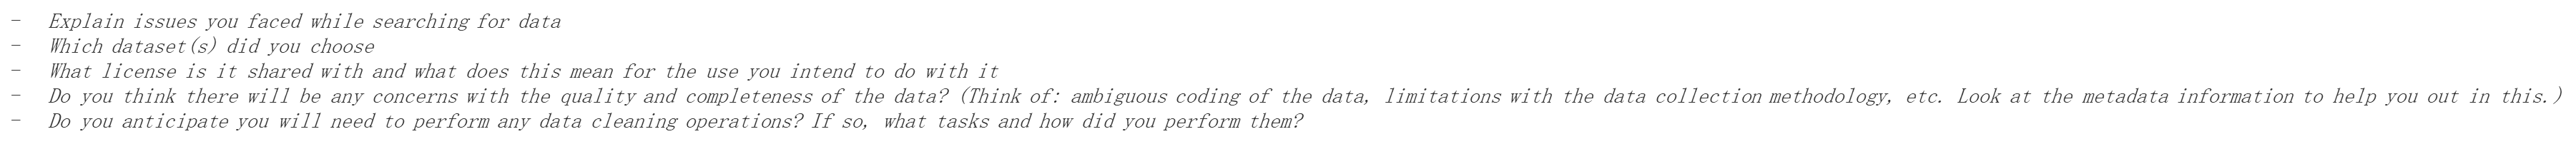

## 第一个问题

STEM学生占比，或他们的薪资水平，是否与国家工业发展有关联？

STEM学生多了会促进国家的工业发展吗？工业发展暗示着STEM行业的高工资吗？

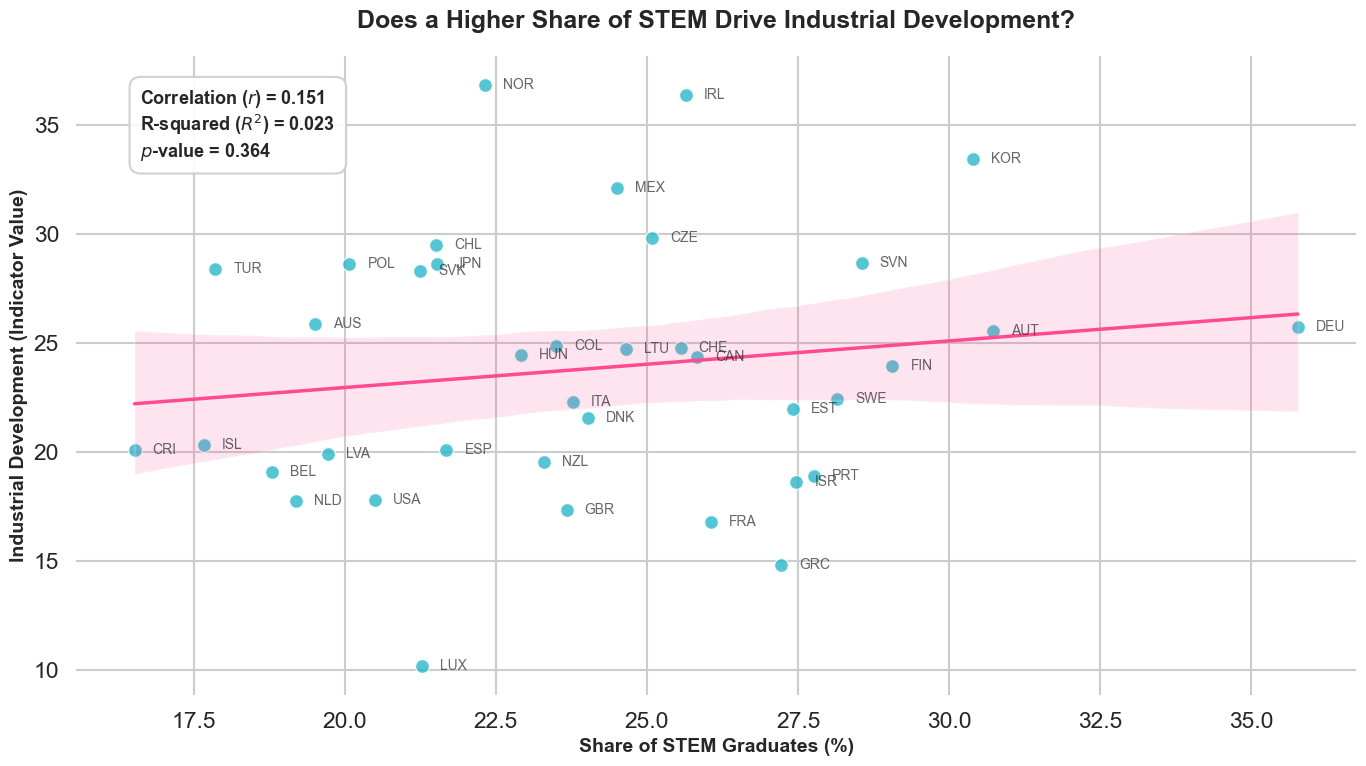

In [304]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats  # 新增：引入统计学计算模块

# 1. 设置图表的高级主题
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

# 2. 核心魔法：计算统计学指标
# 确保排除掉可能含有 NaN 的行（保险起见）
df_stats = df_collapsed.dropna(subset=['Share of STEM', 'Indicator Value'])
x_data = df_stats['Share of STEM']
y_data = df_stats['Indicator Value']

# 计算皮尔逊相关系数 (r) 和 p 值
r_value, p_value = stats.pearsonr(x_data, y_data)
r_squared = r_value ** 2  # 计算决定系数 R²

# 3. 绘制散点图和回归线
ax = sns.regplot(
    data=df_collapsed,
    x='Share of STEM',
    y='Indicator Value',
    scatter_kws={
        's': 100, 'alpha': 0.8, 'edgecolor': 'white', 'color': '#2ab7ca'
    },
    line_kws={
        'color': '#fe4a90', 'linewidth': 2.5
    }
)

# 4. 【核心新增】将统计指标以文本框形式贴在图的左上角
# transform=ax.transAxes 表示使用相对坐标（0.05, 0.95 代表左上角 5% 的位置），不管数据怎么变都不会错位
stats_text = (
    f"Correlation ($r$) = {r_value:.3f}\n"
    f"R-squared ($R^2$) = {r_squared:.3f}\n"
    f"$p$-value = {p_value:.3f}"
)

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    fontweight='semibold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc')
)

# 5. 美化标题和轴标签
plt.title('Does a Higher Share of STEM Drive Industrial Development?',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Share of STEM Graduates (%)', fontsize=14, fontweight='bold')
plt.ylabel('Industrial Development (Indicator Value)', fontsize=14, fontweight='bold')

# 6. 给每个散点加上国家代码
for i in range(df_collapsed.shape[0]):
    x_val = df_collapsed['Share of STEM'].iloc[i]
    y_val = df_collapsed['Indicator Value'].iloc[i]
    country = df_collapsed['Country Code'].iloc[i]
    plt.text(x=x_val + 0.3, y=y_val, s=country, fontsize=10, alpha=0.7, va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

看起来不是非常显著的样子，沾点霰性拟合了。我们再画其他的关系图。

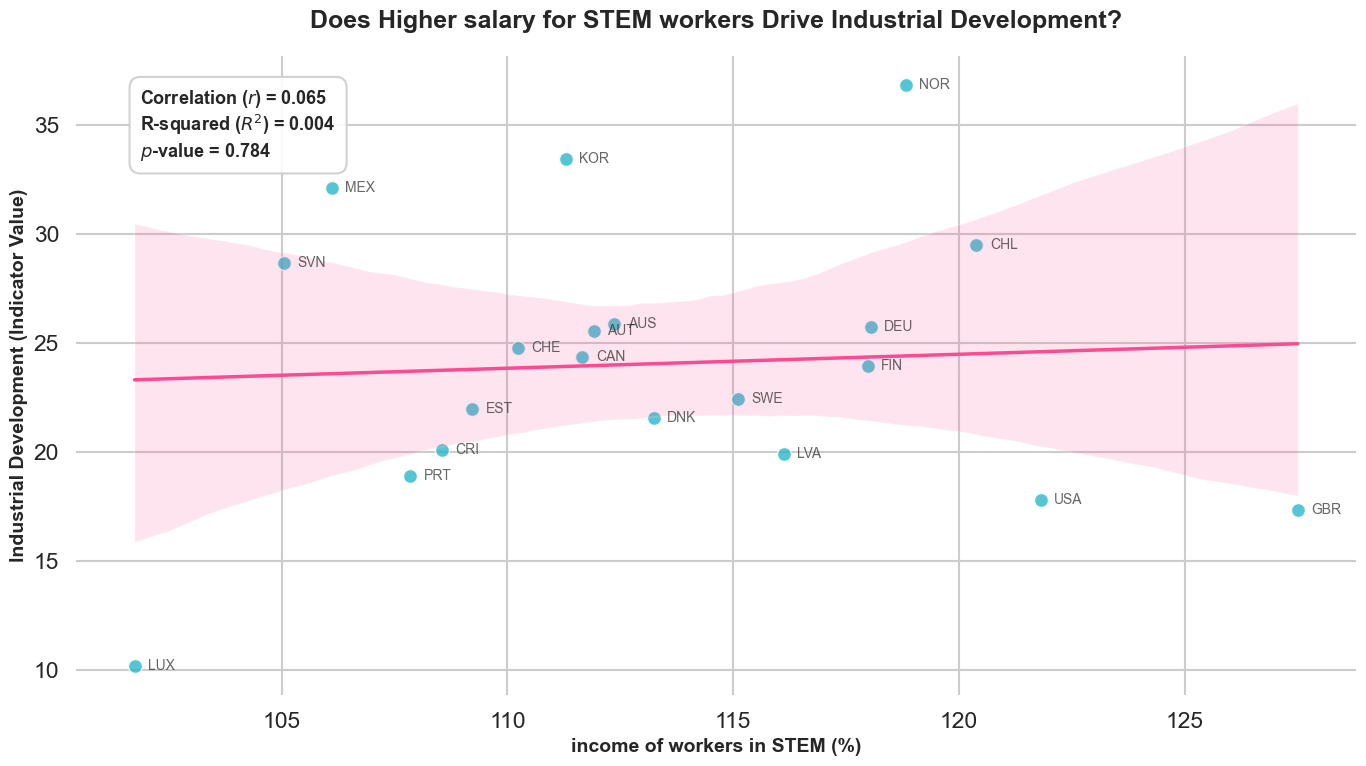

In [305]:
# 1. 设置图表的高级主题
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

# 2. 核心魔法：计算统计学指标
# 确保排除掉可能含有 NaN 的行（保险起见）
df_stats = df_collapsed.dropna(subset=['income of workers in STEM (%)', 'Indicator Value'])
x_data = df_stats['income of workers in STEM (%)']
y_data = df_stats['Indicator Value']

# 计算皮尔逊相关系数 (r) 和 p 值
r_value, p_value = stats.pearsonr(x_data, y_data)
r_squared = r_value ** 2  # 计算决定系数 R²

# 3. 绘制散点图和回归线
ax = sns.regplot(
    data=df_collapsed,
    x='income of workers in STEM (%)',
    y='Indicator Value',
    scatter_kws={
        's': 100, 'alpha': 0.8, 'edgecolor': 'white', 'color': '#2ab7ca'
    },
    line_kws={
        'color': '#fe4a90', 'linewidth': 2.5
    }
)

# 4. 【核心新增】将统计指标以文本框形式贴在图的左上角
# transform=ax.transAxes 表示使用相对坐标（0.05, 0.95 代表左上角 5% 的位置），不管数据怎么变都不会错位
stats_text = (
    f"Correlation ($r$) = {r_value:.3f}\n"
    f"R-squared ($R^2$) = {r_squared:.3f}\n"
    f"$p$-value = {p_value:.3f}"
)

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    fontweight='semibold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc')
)

# 5. 美化标题和轴标签
plt.title('Does Higher salary for STEM workers Drive Industrial Development?',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('income of workers in STEM (%)', fontsize=14, fontweight='bold')
plt.ylabel('Industrial Development (Indicator Value)', fontsize=14, fontweight='bold')

# 6. 给每个散点加上国家代码
for i in range(df_collapsed.shape[0]):
    x_val = df_collapsed['income of workers in STEM (%)'].iloc[i]
    y_val = df_collapsed['Indicator Value'].iloc[i]
    country = df_collapsed['Country Code'].iloc[i]
    plt.text(x=x_val + 0.3, y=y_val, s=country, fontsize=10, alpha=0.7, va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

这个也是没有任何规律可言，p-value大的离谱。

有了这两张图，我们回到原问题：
STEM学生占比，或他们的薪资水平，是否与国家工业发展有关联？

STEM学生多了会促进国家的工业发展吗？工业发展暗示着STEM行业的高工资吗？

我们已经知道了，STEM学生的占比和国家工业水平几乎没有关系，他们的薪资和国家工业水平发展更没关系。至少数据是这样的。

## 第二个问题
那我们进入第二个问题

人均平价购买力和国家的STEM学生占比有没有关系？税后购买力和薪资溢价呢？

是因为技术立国，还是太有钱会让人反而不愿意学习STEM？是税前PPP，还是税后PPP会影响STEM学生比例？亦或是薪资溢价会直接激励人们选择STEM？

那么我们要画的图，就有

* PPP - share of STEM
* PaT - share of STEM
* income - share of STEM

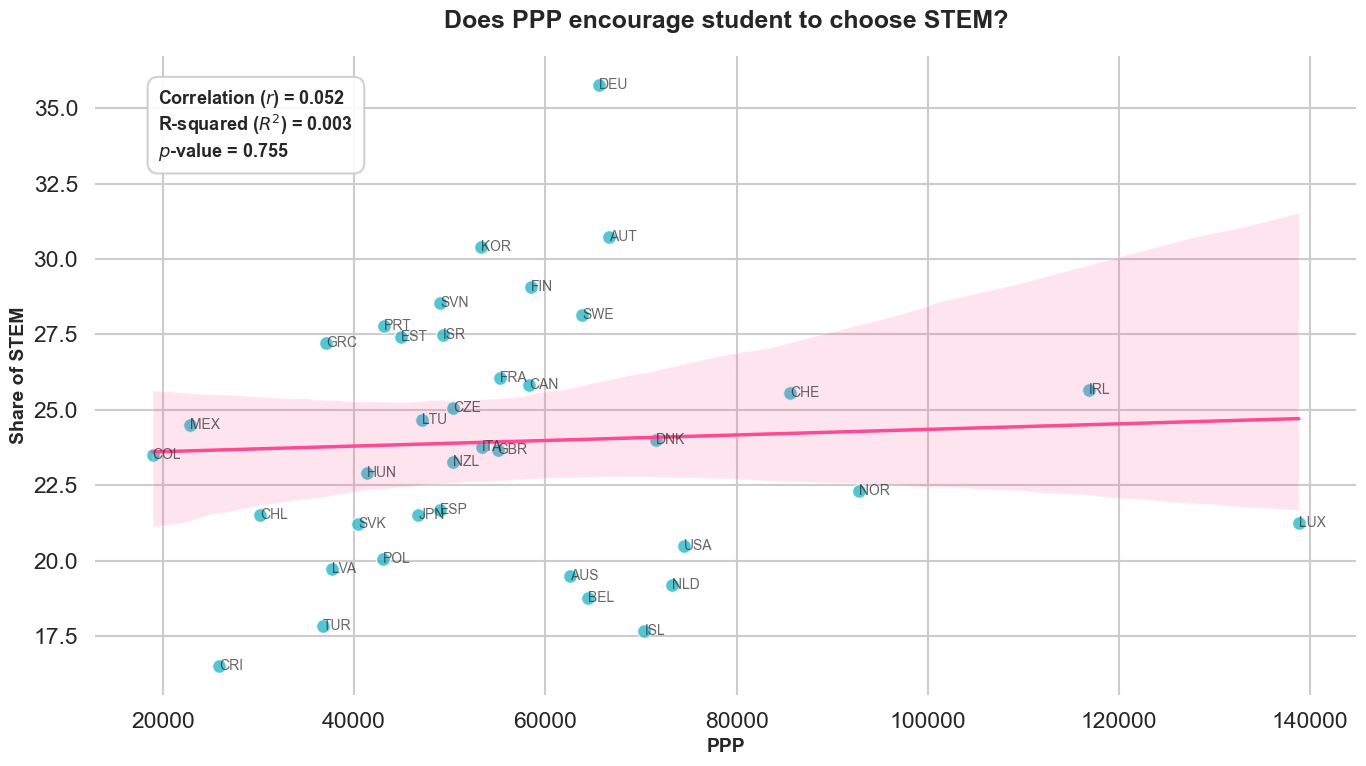

In [306]:
# 1. 设置图表的高级主题
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

# 2. 核心魔法：计算统计学指标
# 确保排除掉可能含有 NaN 的行（保险起见）
df_stats = df_collapsed.dropna(subset=['PPP', 'Share of STEM'])
x_data = df_stats['PPP']
y_data = df_stats['Share of STEM']

# 计算皮尔逊相关系数 (r) 和 p 值
r_value, p_value = stats.pearsonr(x_data, y_data)
r_squared = r_value ** 2  # 计算决定系数 R²

# 3. 绘制散点图和回归线
ax = sns.regplot(
    data=df_collapsed,
    x='PPP',
    y='Share of STEM',
    scatter_kws={
        's': 100, 'alpha': 0.8, 'edgecolor': 'white', 'color': '#2ab7ca'
    },
    line_kws={
        'color': '#fe4a90', 'linewidth': 2.5
    }
)

# 4. 【核心新增】将统计指标以文本框形式贴在图的左上角
# transform=ax.transAxes 表示使用相对坐标（0.05, 0.95 代表左上角 5% 的位置），不管数据怎么变都不会错位
stats_text = (
    f"Correlation ($r$) = {r_value:.3f}\n"
    f"R-squared ($R^2$) = {r_squared:.3f}\n"
    f"$p$-value = {p_value:.3f}"
)

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    fontweight='semibold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc')
)

# 5. 美化标题和轴标签
plt.title('Does PPP encourage student to choose STEM?',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('PPP', fontsize=14, fontweight='bold')
plt.ylabel('Share of STEM', fontsize=14, fontweight='bold')

# 6. 给每个散点加上国家代码
for i in range(df_collapsed.shape[0]):
    x_val = df_collapsed['PPP'].iloc[i]
    y_val = df_collapsed['Share of STEM'].iloc[i]
    country = df_collapsed['Country Code'].iloc[i]
    plt.text(x=x_val + 0.3, y=y_val, s=country, fontsize=10, alpha=0.7, va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

好吧，也没什么关系，

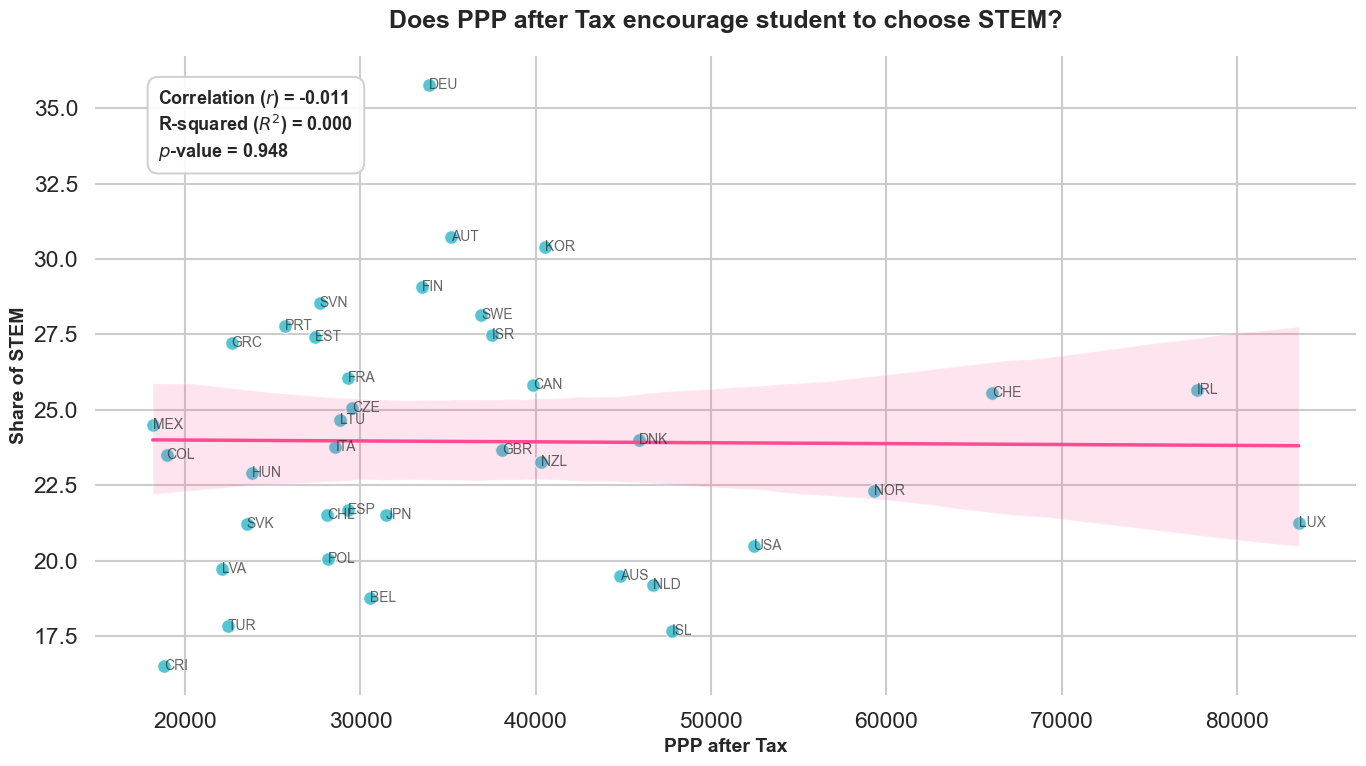

In [308]:
# 1. 设置图表的高级主题
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

# 2. 核心魔法：计算统计学指标
# 确保排除掉可能含有 NaN 的行（保险起见）
df_stats = df_collapsed.dropna(subset=['PPP after Tax', 'Share of STEM'])
x_data = df_stats['PPP after Tax']
y_data = df_stats['Share of STEM']

# 计算皮尔逊相关系数 (r) 和 p 值
r_value, p_value = stats.pearsonr(x_data, y_data)
r_squared = r_value ** 2  # 计算决定系数 R²

# 3. 绘制散点图和回归线
ax = sns.regplot(
    data=df_collapsed,
    x='PPP after Tax',
    y='Share of STEM',
    scatter_kws={
        's': 100, 'alpha': 0.8, 'edgecolor': 'white', 'color': '#2ab7ca'
    },
    line_kws={
        'color': '#fe4a90', 'linewidth': 2.5
    }
)

# 4. 【核心新增】将统计指标以文本框形式贴在图的左上角
# transform=ax.transAxes 表示使用相对坐标（0.05, 0.95 代表左上角 5% 的位置），不管数据怎么变都不会错位
stats_text = (
    f"Correlation ($r$) = {r_value:.3f}\n"
    f"R-squared ($R^2$) = {r_squared:.3f}\n"
    f"$p$-value = {p_value:.3f}"
)

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    fontweight='semibold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc')
)

# 5. 美化标题和轴标签
plt.title('Does PPP after Tax encourage student to choose STEM?',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('PPP after Tax', fontsize=14, fontweight='bold')
plt.ylabel('Share of STEM', fontsize=14, fontweight='bold')

# 6. 给每个散点加上国家代码
for i in range(df_collapsed.shape[0]):
    x_val = df_collapsed['PPP after Tax'].iloc[i]
    y_val = df_collapsed['Share of STEM'].iloc[i]
    country = df_collapsed['Country Code'].iloc[i]
    plt.text(x=x_val + 0.3, y=y_val, s=country, fontsize=10, alpha=0.7, va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

简直是灾难，我们还有最后一个，收入和share of STEM

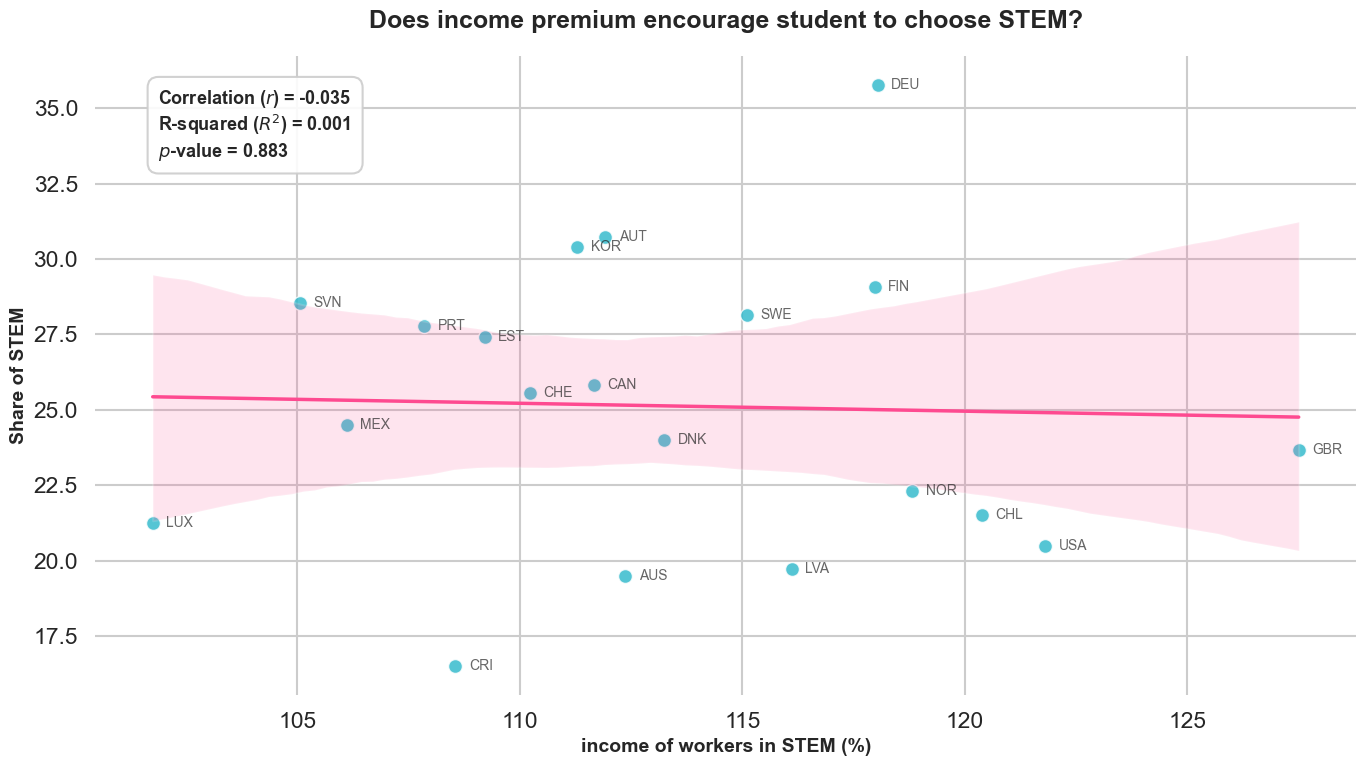

In [309]:
# 1. 设置图表的高级主题
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

# 2. 核心魔法：计算统计学指标
# 确保排除掉可能含有 NaN 的行（保险起见）
df_stats = df_collapsed.dropna(subset=['income of workers in STEM (%)', 'Share of STEM'])
x_data = df_stats['income of workers in STEM (%)']
y_data = df_stats['Share of STEM']

# 计算皮尔逊相关系数 (r) 和 p 值
r_value, p_value = stats.pearsonr(x_data, y_data)
r_squared = r_value ** 2  # 计算决定系数 R²

# 3. 绘制散点图和回归线
ax = sns.regplot(
    data=df_collapsed,
    x='income of workers in STEM (%)',
    y='Share of STEM',
    scatter_kws={
        's': 100, 'alpha': 0.8, 'edgecolor': 'white', 'color': '#2ab7ca'
    },
    line_kws={
        'color': '#fe4a90', 'linewidth': 2.5
    }
)

# 4. 【核心新增】将统计指标以文本框形式贴在图的左上角
# transform=ax.transAxes 表示使用相对坐标（0.05, 0.95 代表左上角 5% 的位置），不管数据怎么变都不会错位
stats_text = (
    f"Correlation ($r$) = {r_value:.3f}\n"
    f"R-squared ($R^2$) = {r_squared:.3f}\n"
    f"$p$-value = {p_value:.3f}"
)

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    fontweight='semibold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc')
)

# 5. 美化标题和轴标签
plt.title('Does income premium encourage student to choose STEM?',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('income of workers in STEM (%)', fontsize=14, fontweight='bold')
plt.ylabel('Share of STEM', fontsize=14, fontweight='bold')

# 6. 给每个散点加上国家代码
for i in range(df_collapsed.shape[0]):
    x_val = df_collapsed['income of workers in STEM (%)'].iloc[i]
    y_val = df_collapsed['Share of STEM'].iloc[i]
    country = df_collapsed['Country Code'].iloc[i]
    plt.text(x=x_val + 0.3, y=y_val, s=country, fontsize=10, alpha=0.7, va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

太离谱了，没想到前几个问题都是完全不相关。就连工资激励和比例都没关系。

### 第三个问题
太离谱了，都不相关，我们赶紧来看第3个问题。
税率本身是否影响国家工业发展有关联？是更多赋税促进工业，还是太多赋税阻碍工业？

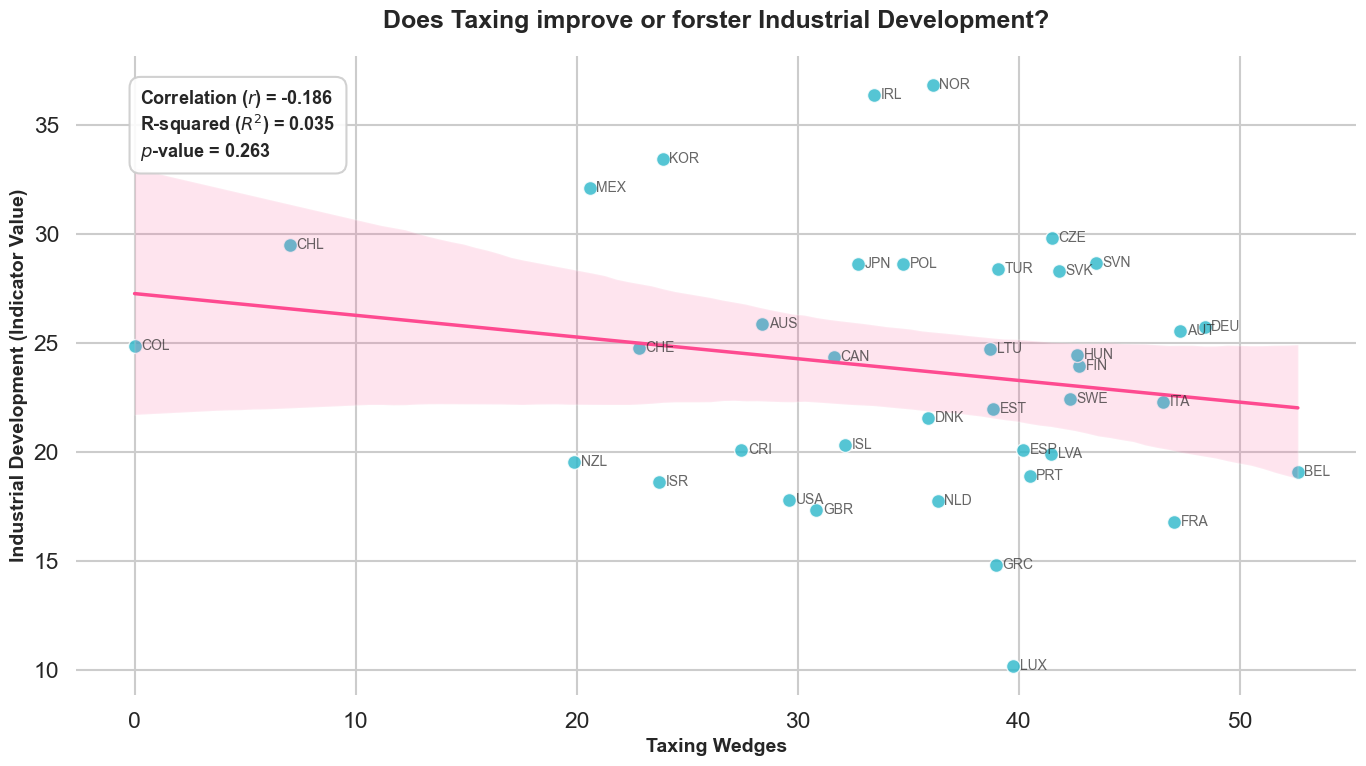

In [292]:
# 1. 设置图表的高级主题
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 8))

# 2. 核心魔法：计算统计学指标
# 确保排除掉可能含有 NaN 的行（保险起见）
df_stats = df_collapsed.dropna(subset=['Taxing Wedges', 'Indicator Value'])
x_data = df_stats['Taxing Wedges']
y_data = df_stats['Indicator Value']

# 计算皮尔逊相关系数 (r) 和 p 值
r_value, p_value = stats.pearsonr(x_data, y_data)
r_squared = r_value ** 2  # 计算决定系数 R²

# 3. 绘制散点图和回归线
ax = sns.regplot(
    data=df_collapsed,
    x='Taxing Wedges',
    y='Indicator Value',
    scatter_kws={
        's': 100, 'alpha': 0.8, 'edgecolor': 'white', 'color': '#2ab7ca'
    },
    line_kws={
        'color': '#fe4a90', 'linewidth': 2.5
    }
)

# 4. 【核心新增】将统计指标以文本框形式贴在图的左上角
# transform=ax.transAxes 表示使用相对坐标（0.05, 0.95 代表左上角 5% 的位置），不管数据怎么变都不会错位
stats_text = (
    f"Correlation ($r$) = {r_value:.3f}\n"
    f"R-squared ($R^2$) = {r_squared:.3f}\n"
    f"$p$-value = {p_value:.3f}"
)

ax.text(
    0.05, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=13,
    verticalalignment='top',
    fontweight='semibold',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc')
)

# 5. 美化标题和轴标签
plt.title('Does Taxing improve or forster Industrial Development?',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Taxing Wedges', fontsize=14, fontweight='bold')
plt.ylabel('Industrial Development (Indicator Value)', fontsize=14, fontweight='bold')

# 6. 给每个散点加上国家代码
for i in range(df_collapsed.shape[0]):
    x_val = df_collapsed['Taxing Wedges'].iloc[i]
    y_val = df_collapsed['Indicator Value'].iloc[i]
    country = df_collapsed['Country Code'].iloc[i]
    plt.text(x=x_val + 0.3, y=y_val, s=country, fontsize=10, alpha=0.7, va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 进阶探索
挺尴尬的，所有数据都没有明显的关联性，我们根据gemini的建议，考虑分组看看效果

📊 自动计算的 OECD 国家税收中位数门槛为: 37.52%

分组计算的平均值结果：
  Tax Group  Share of STEM  Indicator Value
0  High Tax      25.140070        22.425015
1   Low Tax      22.772065        25.178484


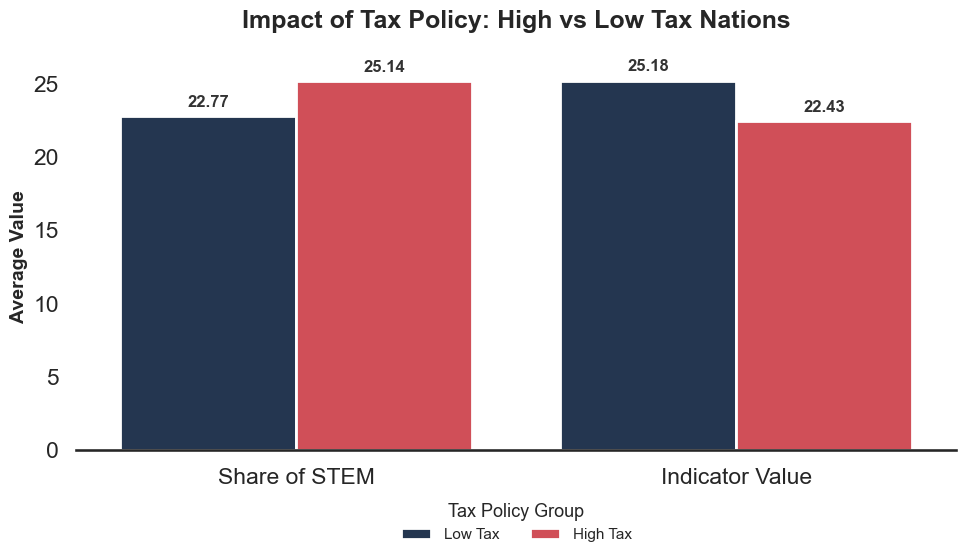

In [302]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. 确保你已经运行过之前的分组计算，得到了 df_grouped
# # 1. 采用 Taxing Wedges 的中位数（Median）作为划分高低税收的科学门槛
tax_median = df_collapsed['Taxing Wedges'].median()
print(f"📊 自动计算的 OECD 国家税收中位数门槛为: {tax_median:.2f}%")

# 2. 条件划分：大于中位数的打上 'High Tax' 标签，否则打上 'Low Tax' 标签
df_collapsed['Tax Group'] = np.where(
    df_collapsed['Taxing Wedges'] > tax_median,
    'High Tax',
    'Low Tax'
)

# 3. 按 Tax Group 分组，一键计算两组的平均值
df_grouped = df_collapsed.groupby('Tax Group')[['Share of STEM', 'Indicator Value']].mean().reset_index()

print("\n分组计算的平均值结果：")
print(df_grouped)

# 2. 宽表拉直（Melt）：把两项指标竖过来，方便 seaborn 画并排柱子
df_melted_grouped = pd.melt(
    df_grouped,
    id_vars='Tax Group',
    value_vars=['Share of STEM', 'Indicator Value'],
    var_name='Metric',
    value_name='Average Value'
)

# 3. 开始绘制高颜值对比图
sns.set_theme(style="white", context="talk")  # 纯白极简背景
plt.figure(figsize=(10, 6))

# 设置高级对比配色 (低税收用深海蓝，高税收用珊瑚红)
custom_palette = {"Low Tax": "#1d3557", "High Tax": "#e63946"}

ax = sns.barplot(
    data=df_melted_grouped,
    x='Metric',
    y='Average Value',
    hue='Tax Group',      # 根据税收分组区分颜色
    hue_order=['Low Tax', 'High Tax'],
    palette=custom_palette,
    edgecolor="white",    # 柱子加白边，增加立体感
    linewidth=2
)

# 4. 精细化打磨图表元素
plt.title('Impact of Tax Policy: High vs Low Tax Nations',
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('')  # 隐藏底部默认的 Metric 标签
plt.ylabel('Average Value', fontsize=14, fontweight='bold')

# 去掉左侧和上方多余边框，只留地平线
sns.despine(left=True, bottom=False)

# 5. 【点睛之笔】直接在柱子顶部标注精确的平均值
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=12, fontweight='bold', color='#333333')

# 6. 优化图例，将其放在底部中心，避免遮挡数据
plt.legend(title='Tax Policy Group', title_fontsize='13', fontsize='11',
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

低税国家反而STEM学生少一些，但同时经济发展指数高一点。接下来，我们再看看极端组。

🟢 税收最低的 5 个国家： ['COL', 'CHL', 'NZL', 'MEX', 'CHE']
🔴 税收最高的 5 个国家： ['BEL', 'DEU', 'AUT', 'FRA', 'ITA']


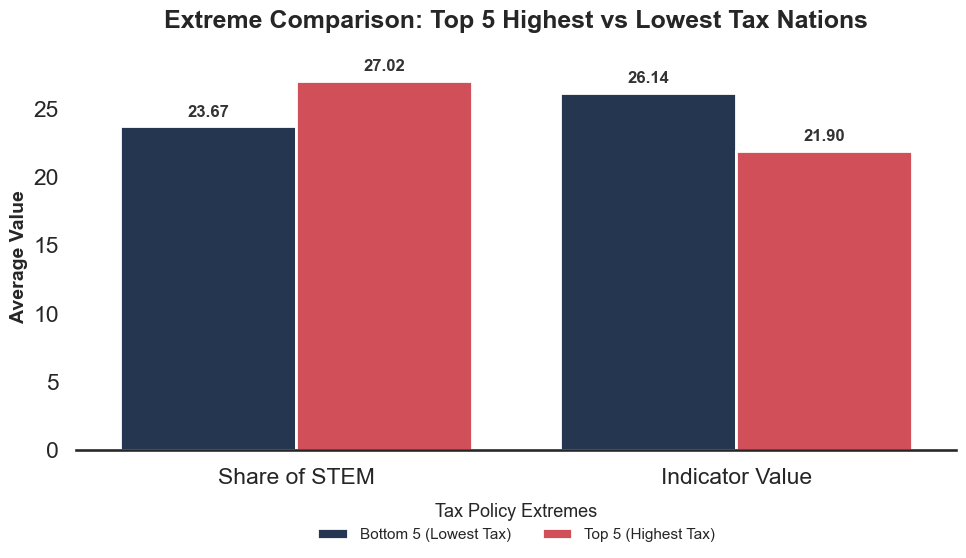

In [303]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. 揪出极端值：提取税收最低的 5 个和最高的 5 个国家
bottom5_tax = df_collapsed.nsmallest(5, 'Taxing Wedges').copy()
top5_tax = df_collapsed.nlargest(5, 'Taxing Wedges').copy()

# 给他们打上识别标签
bottom5_tax['Extremes'] = 'Bottom 5 (Lowest Tax)'
top5_tax['Extremes'] = 'Top 5 (Highest Tax)'

# 把这两组拼成一个新的小表
df_extremes = pd.concat([bottom5_tax, top5_tax])

# 打印一下名单，做到心里有数
print("🟢 税收最低的 5 个国家：", bottom5_tax['Country Code'].tolist())
print("🔴 税收最高的 5 个国家：", top5_tax['Country Code'].tolist())

# 2. 计算这两组的平均值
df_extreme_avg = df_extremes.groupby('Extremes')[['Share of STEM', 'Indicator Value']].mean().reset_index()

# 3. 【核心美化技巧】把宽表拉直，方便画并排对比图
df_melted_extremes = pd.melt(
    df_extreme_avg,
    id_vars='Extremes',
    value_vars=['Share of STEM', 'Indicator Value'],
    var_name='Metric',
    value_name='Average Value'
)

# 4. 开始绘制高颜值对比图
sns.set_theme(style="white", context="talk") # 使用最干净的纯白背景
plt.figure(figsize=(10, 6))

# 设置一组具有强烈对比的商业化配色（深海蓝 vs 珊瑚红）
custom_palette = {"Bottom 5 (Lowest Tax)": "#1d3557", "Top 5 (Highest Tax)": "#e63946"}

ax = sns.barplot(
    data=df_melted_extremes,
    x='Metric',
    y='Average Value',
    hue='Extremes',
    palette=custom_palette,
    edgecolor="white",    # 柱子加白边，显得更精致
    linewidth=2
)

# 5. 精细化打磨图表元素
plt.title('Extreme Comparison: Top 5 Highest vs Lowest Tax Nations',
          fontsize=18, fontweight='bold', pad=25)
plt.xlabel('') # 隐藏底部的 Metric 标签，因为文字已经很清楚了
plt.ylabel('Average Value', fontsize=14, fontweight='bold')

# 去掉上、右、左侧的多余边框线，只留一条地平线
sns.despine(left=True, bottom=False)

# 6. 【超加分项】直接在柱子上标注精确的数值！
# 这样老师都不用看纵坐标估算，一眼就能看出差距
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5, fontsize=12, fontweight='bold', color='#333333')

# 优化图例位置和样式
plt.legend(title='Tax Policy Extremes', title_fontsize='13', fontsize='11',
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

这张图终于有意思了一点，我们发现尽管之前的规律非常弱，但是极端低和极端高的差别还是挺大的。